In [ ]:
# ======================================================================
# SECTION 1: IMPORT LIBRARIES
# ======================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, log_loss)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.calibration import calibration_curve

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Install and import explainability libraries
# !pip install shap
import shap

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# ======================================================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ======================================================================
# Load the dataset
df = pd.read_csv('Mobile_Price_Predict.csv')

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

print("\n" + "="*60)
print("FIRST FEW ROWS")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing_vals = df.isnull().sum()
display(missing_vals[missing_vals > 0])
if missing_vals.sum() == 0:
    print("No missing values found!")

DATASET OVERVIEW

Dataset Shape: (2000, 21)
Number of Samples: 2000
Number of Features: 21

FIRST FEW ROWS


,Battery_Power,Clock_Speed,FC,Int_Memory,Mobile_D,Mobile_W,Cores,PC,Pixel_H,Pixel_W,...,Screen_H,Screen_W,Talk_Time,Four_G,Three_G,Touch_Screen,Dual_SIM,Bluetooth,WiFi,Price_Range
0,842,2.2,1,7,0.6,188,2,2,20,756,...,9,7,19,0,0,0,0,0,1,1
1,1021,0.5,0,53,0.7,136,3,6,905,1988,...,17,3,7,1,1,1,1,1,0,2
2,563,0.5,2,41,0.9,145,5,6,1263,1716,...,11,2,9,1,1,1,1,1,0,2
3,615,2.5,0,10,0.8,131,6,9,1216,1786,...,16,8,11,0,1,0,0,1,0,2
4,1821,1.2,13,44,0.6,141,2,14,1208,1212,...,8,2,15,1,1,1,0,1,0,1



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Battery_Power  2000 non-null   int64  
 1   Clock_Speed    2000 non-null   float64
 2   FC             2000 non-null   int64  
 3   Int_Memory     2000 non-null   int64  
 4   Mobile_D       2000 non-null   float64
 5   Mobile_W       2000 non-null   int64  
 6   Cores          2000 non-null   int64  
 7   PC             2000 non-null   int64  
 8   Pixel_H        2000 non-null   int64  
 9   Pixel_W        2000 non-null   int64  
 10  Ram            2000 non-null   int64  
 11  Screen_H       2000 non-null   int64  
 12  Screen_W       2000 non-null   int64  
 13  Talk_Time      2000 non-null   int64  
 14  Four_G         2000 non-null   int64  
 15  Three_G        2000 non-null   int64  
 16  Touch_Screen   2000 non-null   int64  
 17  Dual_SIM       2000 non-null   

,Battery_Power,Clock_Speed,FC,Int_Memory,Mobile_D,Mobile_W,Cores,PC,Pixel_H,Pixel_W,...,Screen_H,Screen_W,Talk_Time,Four_G,Three_G,Touch_Screen,Dual_SIM,Bluetooth,WiFi,Price_Range
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000
mean,1238.518500,1.522250,4.309500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,...,12.306500,5.767000,11.011000,0.521500,0.761500,0.503000,0.509500,0.4950,0.507000,1.500000
std,439.418206,0.816004,4.341444,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,...,4.213245,4.356398,5.463955,0.499662,0.426273,0.500116,0.500035,0.5001,0.500076,1.118314
min,501.000000,0.500000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,...,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
25%,851.750000,0.700000,1.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,...,9.000000,2.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.0000,0.000000,0.750000
50%,1226.000000,1.500000,3.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,...,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.000000,0.0000,1.000000,1.500000
75%,1615.250000,2.200000,7.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,...,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,2.250000
max,1998.000000,3.000000,19.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,...,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,3.000000



MISSING VALUES


,0


No missing values found!


In [ ]:
# ======================================================================
# SECTION 3: DATA QUALITY CHECKS
# ======================================================================
print("="*60)
print("DATA QUALITY CHECKS")
print("="*60)

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
(df['Price_Range'].value_counts().sort_index())
print(f"\nTarget variable balance:\n{df['Price_Range'].value_counts(normalize=True).sort_index() * 100}")

# Verify all binary columns
binary_cols = ['Four_G', 'Three_G', 'Touch_Screen', 'Dual_SIM', 'Bluetooth', 'WiFi']
print("\n" + "="*60)
print("BINARY FEATURES CHECK")
print("="*60)
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

DATA QUALITY CHECKS

Number of duplicate rows: 0

DATA TYPES
Battery_Power      int64
Clock_Speed      float64
FC                 int64
Int_Memory         int64
Mobile_D         float64
Mobile_W           int64
Cores              int64
PC                 int64
Pixel_H            int64
Pixel_W            int64
Ram                int64
Screen_H           int64
Screen_W           int64
Talk_Time          int64
Four_G             int64
Three_G            int64
Touch_Screen       int64
Dual_SIM           int64
Bluetooth          int64
WiFi               int64
Price_Range        int64
dtype: object

TARGET VARIABLE DISTRIBUTION

Target variable balance:
Price_Range
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

BINARY FEATURES CHECK
Four_G: [0 1]
Three_G: [0 1]
Touch_Screen: [0 1]
Dual_SIM: [0 1]
Bluetooth: [0 1]
WiFi: [1 0]


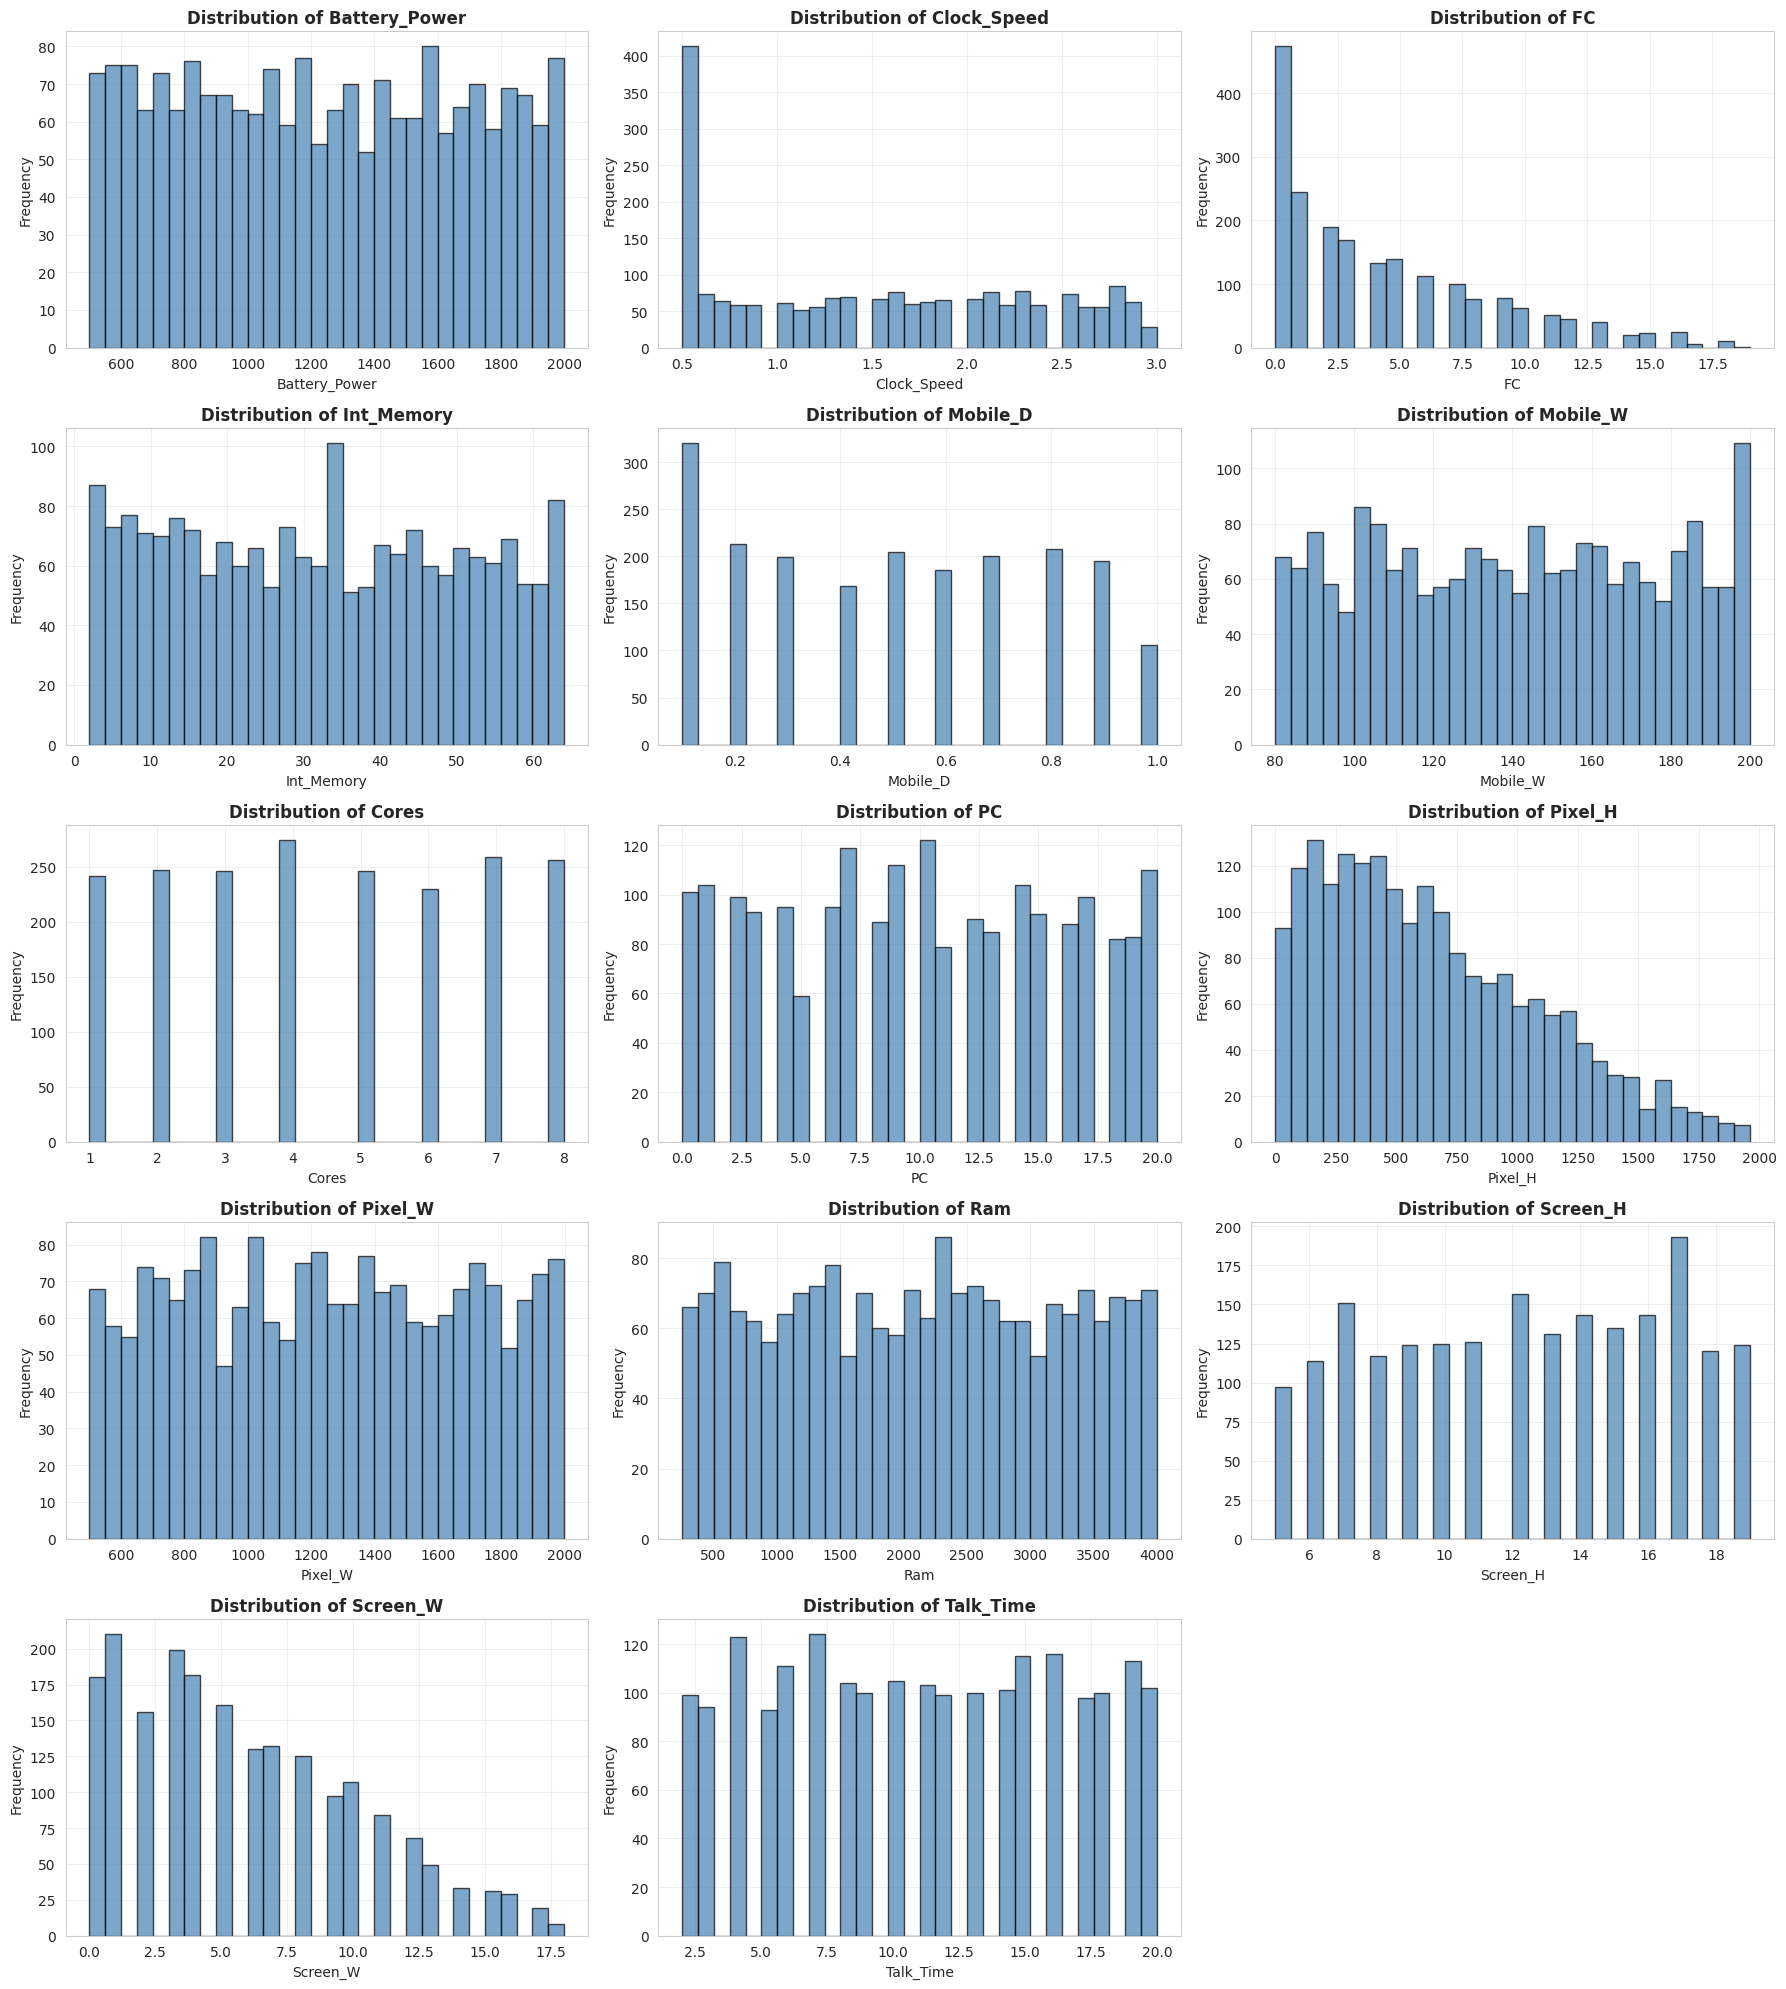

Distribution plots created successfully!


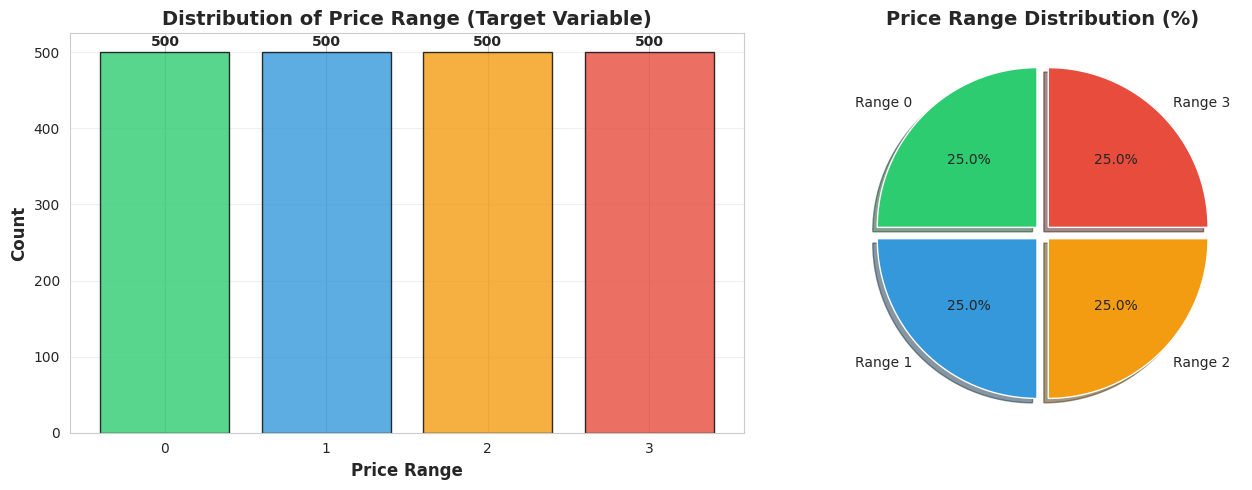

Target variable is balanced across all classes!


In [ ]:
# ======================================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS - VISUALIZATIONS
# ======================================================================
# Visualize distributions of numerical features
numerical_features = ['Battery_Power', 'Clock_Speed', 'FC', 'Int_Memory', 'Mobile_D',
                     'Mobile_W', 'Cores', 'PC', 'Pixel_H', 'Pixel_W', 'Ram',
                     'Screen_H', 'Screen_W', 'Talk_Time']

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Distribution plots created successfully!")

# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_counts = df['Price_Range'].value_counts().sort_index()
axes[0].bar(price_counts.index, price_counts.values, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
           edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Price Range', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Price Range (Target Variable)', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1, 2, 3])
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(price_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[1].pie(price_counts.values, labels=[f'Range {i}' for i in price_counts.index],
           autopct='%1.1f%%', colors=colors, startangle=90,
           explode=[0.05, 0.05, 0.05, 0.05], shadow=True)
axes[1].set_title('Price Range Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Target variable is balanced across all classes!")

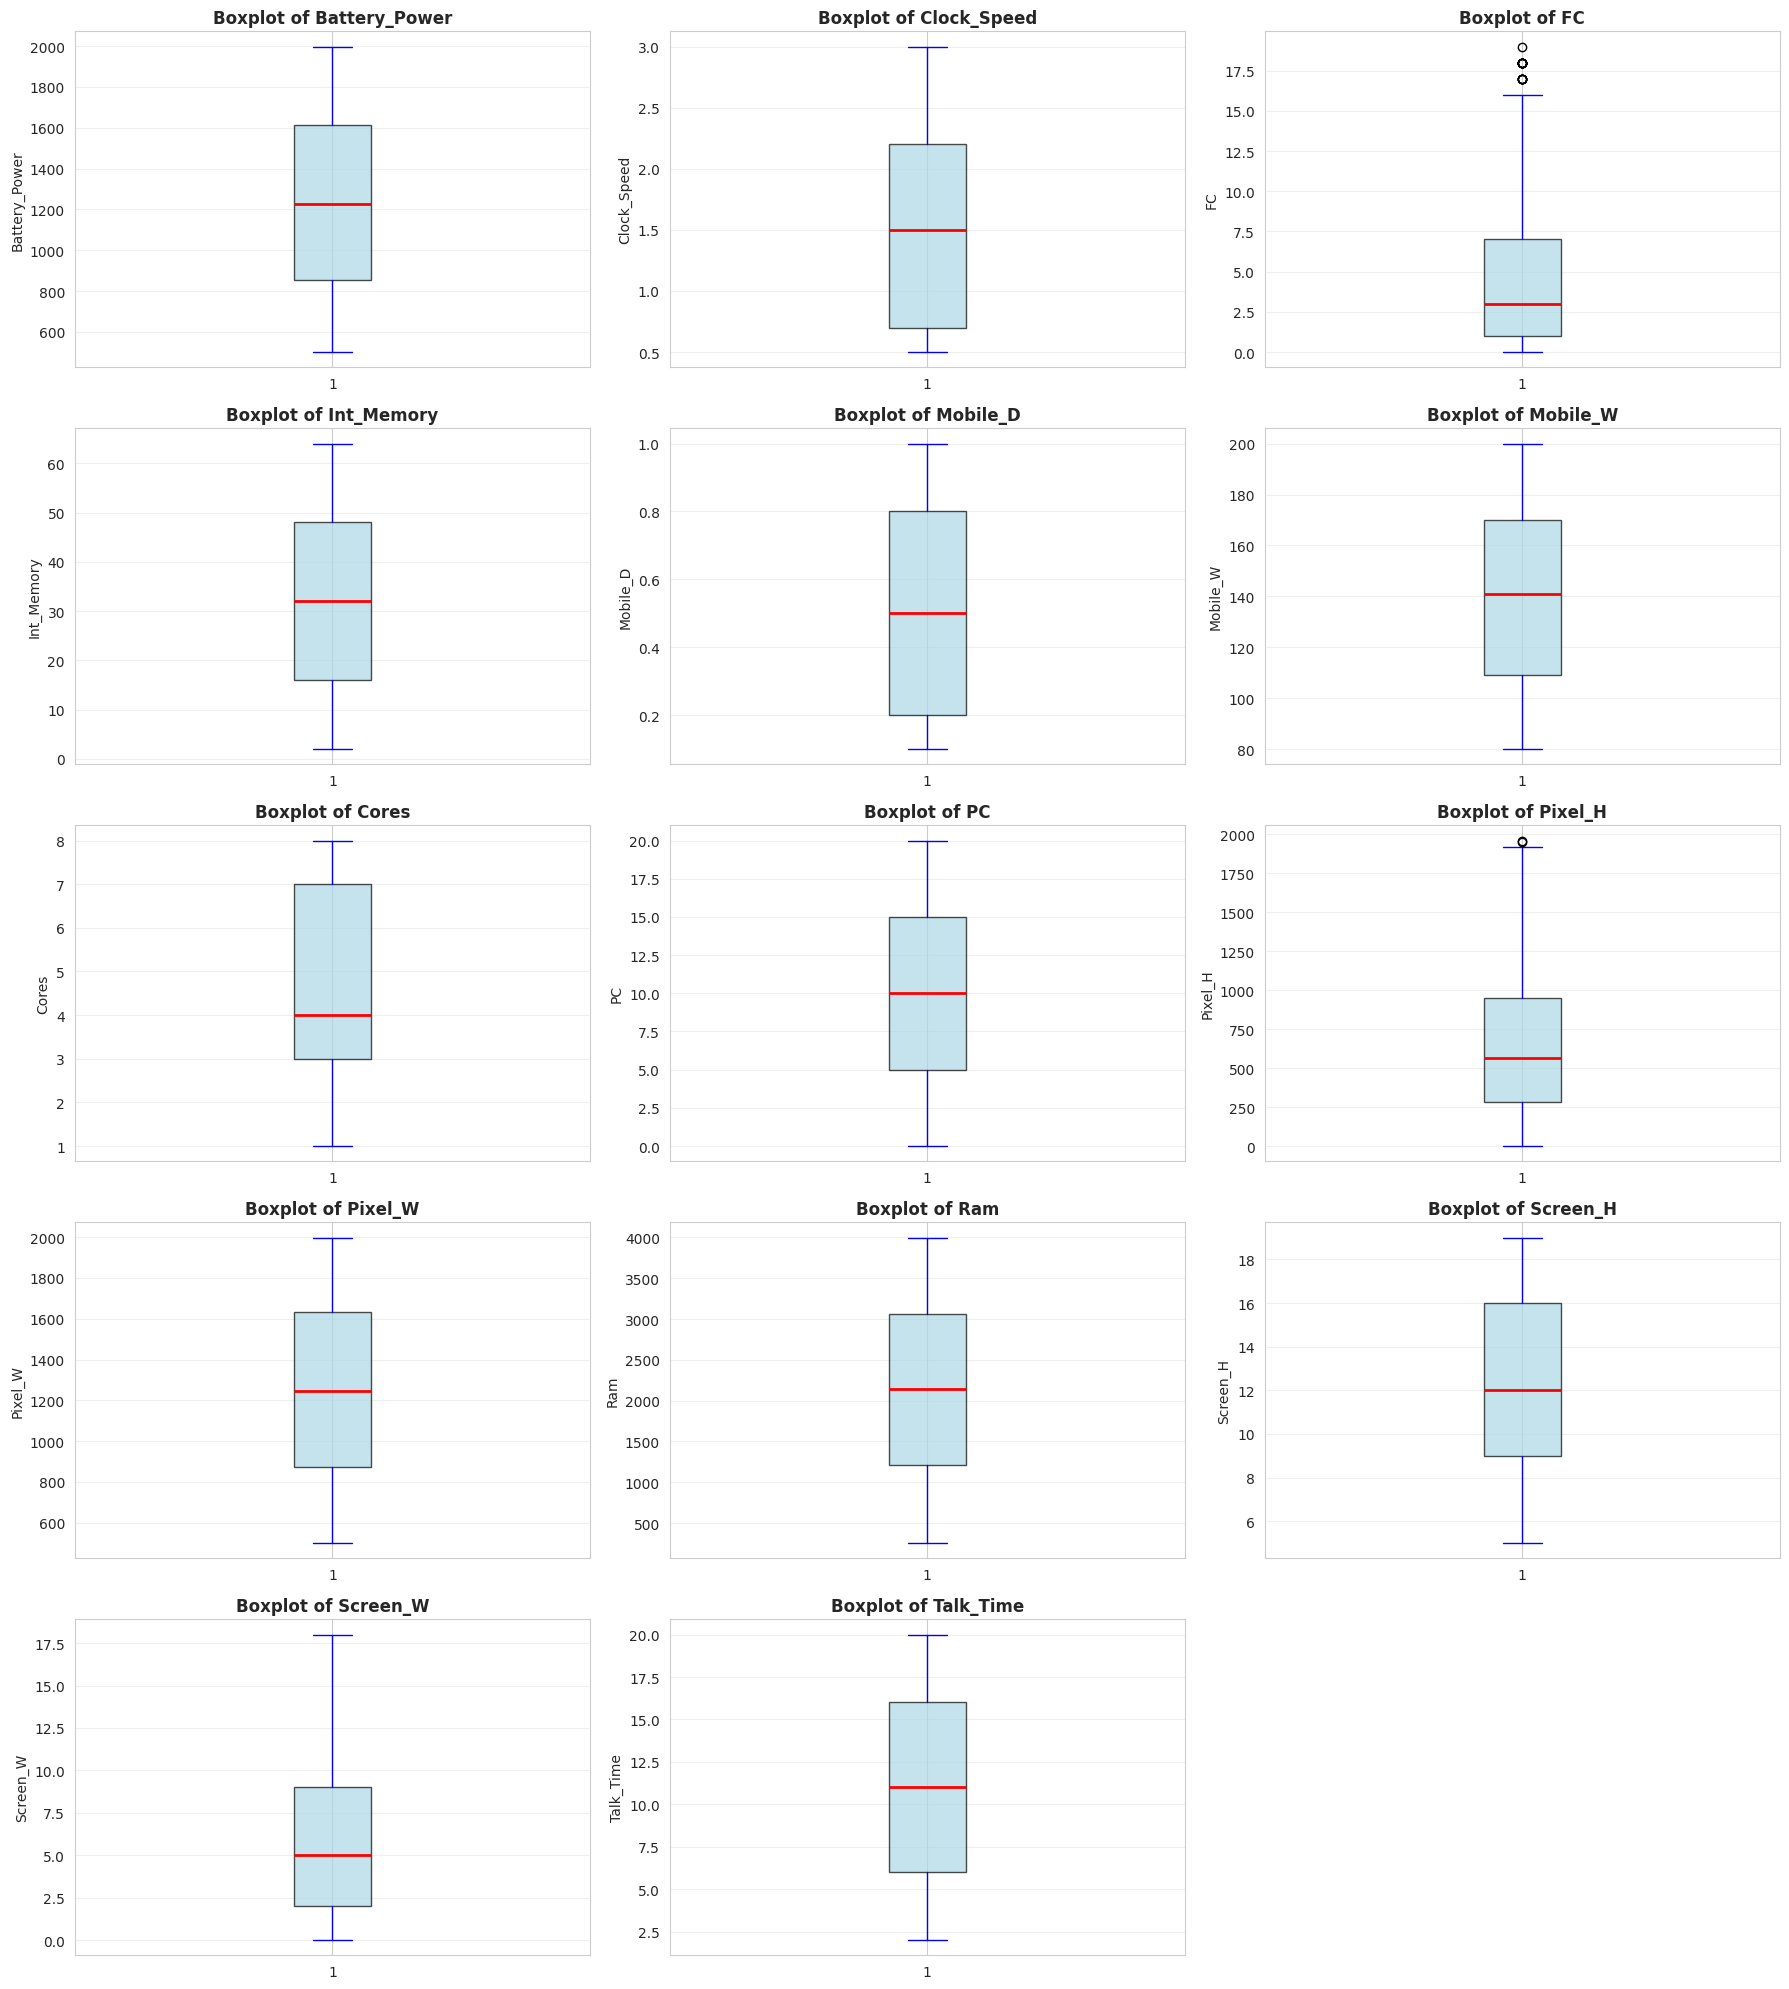

In [ ]:
# ======================================================================
# SECTION 5: OUTLIER DETECTION
# ======================================================================
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.ravel()

outlier_summary = {}

for idx, col in enumerate(numerical_features):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='blue'),
                     capprops=dict(color='blue'))
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3, axis='y')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(df)) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ======================================================================
# SECTION 6: OUTLIER TREATMENT
# ======================================================================
df_treated = df.copy()

print("="*60)
print("OUTLIER TREATMENT")
print("="*60)
print("\nApplying Winsorization (Capping) method...")
print("Outliers will be capped at 1st and 99th percentiles\n")

treatment_summary = {}

for col in numerical_features:
    p01 = df_treated[col].quantile(0.01)
    p99 = df_treated[col].quantile(0.99)

    lower_outliers = (df_treated[col] < p01).sum()
    upper_outliers = (df_treated[col] > p99).sum()

    df_treated[col] = np.clip(df_treated[col], p01, p99)

    treatment_summary[col] = {
        'lower_capped': lower_outliers,
        'upper_capped': upper_outliers,
        'total_treated': lower_outliers + upper_outliers
    }

print(f"{'Feature':<15} {'Lower Capped':<15} {'Upper Capped':<15} {'Total Treated':<15}")
print("="*60)
for feature, stats in treatment_summary.items():
    if stats['total_treated'] > 0:
        print(f"{feature:<15} {stats['lower_capped']:<15} {stats['upper_capped']:<15} {stats['total_treated']:<15}")

print("\n" + "="*60)
print(f"Original dataset shape: {df.shape}")
print(f"Treated dataset shape: {df_treated.shape}")
print("No data points were removed, only capped!")
print("="*60)

OUTLIER TREATMENT

Applying Winsorization (Capping) method...
Outliers will be capped at 1st and 99th percentiles

Feature         Lower Capped    Upper Capped    Total Treated  
Battery_Power   19              19              38             
FC              0               18              18             
Mobile_W        0               19              19             
Pixel_H         19              20              39             
Pixel_W         20              19              39             
Ram             20              20              40             
Screen_W        0               8               8              

Original dataset shape: (2000, 21)
Treated dataset shape: (2000, 21)
No data points were removed, only capped!


In [ ]:
# ======================================================================
# SECTION 7: FEATURE ENGINEERING (MOVED BEFORE CORRELATION ANALYSIS)
# ======================================================================
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Create pixel density (total pixels)
df_treated['Total_Pixels'] = df_treated['Pixel_H'] * df_treated['Pixel_W']
print("✓ Created 'Total_Pixels': Height × Width")

# Create screen size (diagonal approximation)
df_treated['Screen_Size'] = np.sqrt(df_treated['Screen_H']**2 + df_treated['Screen_W']**2)
print("✓ Created 'Screen_Size': Diagonal screen measurement")

# Create pixel density per cm
screen_area = df_treated['Screen_H'] * df_treated['Screen_W']
df_treated['Pixel_Density'] = np.where(screen_area > 0,
                                       df_treated['Total_Pixels'] / screen_area,
                                       0)
print("✓ Created 'Pixel_Density': Pixels per square cm")

# Total camera megapixels
df_treated['Total_Camera_MP'] = df_treated['FC'] + df_treated['PC']
print("✓ Created 'Total_Camera_MP': Front + Primary camera")

# Mobile aspect ratio
df_treated['Aspect_Ratio'] = np.where(df_treated['Mobile_W'] > 0,
                                      df_treated['Mobile_D'] / df_treated['Mobile_W'],
                                      0)
print("✓ Created 'Aspect_Ratio': Depth to Width ratio")

# Battery efficiency
df_treated['Battery_Efficiency'] = np.where(df_treated['Battery_Power'] > 0,
                                            df_treated['Talk_Time'] / (df_treated['Battery_Power'] / 1000),
                                            0)
print("✓ Created 'Battery_Efficiency': Talk time per battery unit")

# Connectivity score
df_treated['Connectivity_Score'] = (df_treated['Four_G'] + df_treated['Three_G'] +
                                   df_treated['Bluetooth'] + df_treated['WiFi'])
print("✓ Created 'Connectivity_Score': Sum of connectivity features")

# Processing power indicator
df_treated['Processing_Power'] = df_treated['Cores'] * df_treated['Clock_Speed']
print("✓ Created 'Processing_Power': Cores × Clock Speed")

# Replace any remaining inf or -inf values with 0
df_treated = df_treated.replace([np.inf, -np.inf], 0)

if df_treated.isnull().sum().sum() > 0:
    print("\n⚠ Warning: Some NaN values were created during feature engineering")
    print("Filling NaN values with 0...")
    df_treated = df_treated.fillna(0)

print("\n" + "="*60)
print(f"Total features after engineering: {df_treated.shape[1]}")
print(f"New features created: {df_treated.shape[1] - df.shape[1]}")
print("✓ All infinite and NaN values handled safely!")
print("="*60)

print("\nSample of engineered features:")
display(df_treated[['Total_Pixels', 'Screen_Size', 'Pixel_Density', 'Total_Camera_MP',
                 'Connectivity_Score', 'Processing_Power']].head())


FEATURE ENGINEERING
✓ Created 'Total_Pixels': Height × Width
✓ Created 'Screen_Size': Diagonal screen measurement
✓ Created 'Pixel_Density': Pixels per square cm
✓ Created 'Total_Camera_MP': Front + Primary camera
✓ Created 'Aspect_Ratio': Depth to Width ratio
✓ Created 'Battery_Efficiency': Talk time per battery unit
✓ Created 'Connectivity_Score': Sum of connectivity features
✓ Created 'Processing_Power': Cores × Clock Speed

Total features after engineering: 29
New features created: 8
✓ All infinite and NaN values handled safely!

Sample of engineered features:


,Total_Pixels,Screen_Size,Pixel_Density,Total_Camera_MP,Connectivity_Score,Processing_Power
0,15120.0,11.401754,240.000000,3,1,4.4
1,1798235.0,17.262677,35259.509804,6,3,1.5
2,2167308.0,11.180340,98514.000000,8,3,2.5
3,2171776.0,17.888544,16967.000000,9,2,15.0
4,1464096.0,8.246211,91506.000000,27,3,2.4


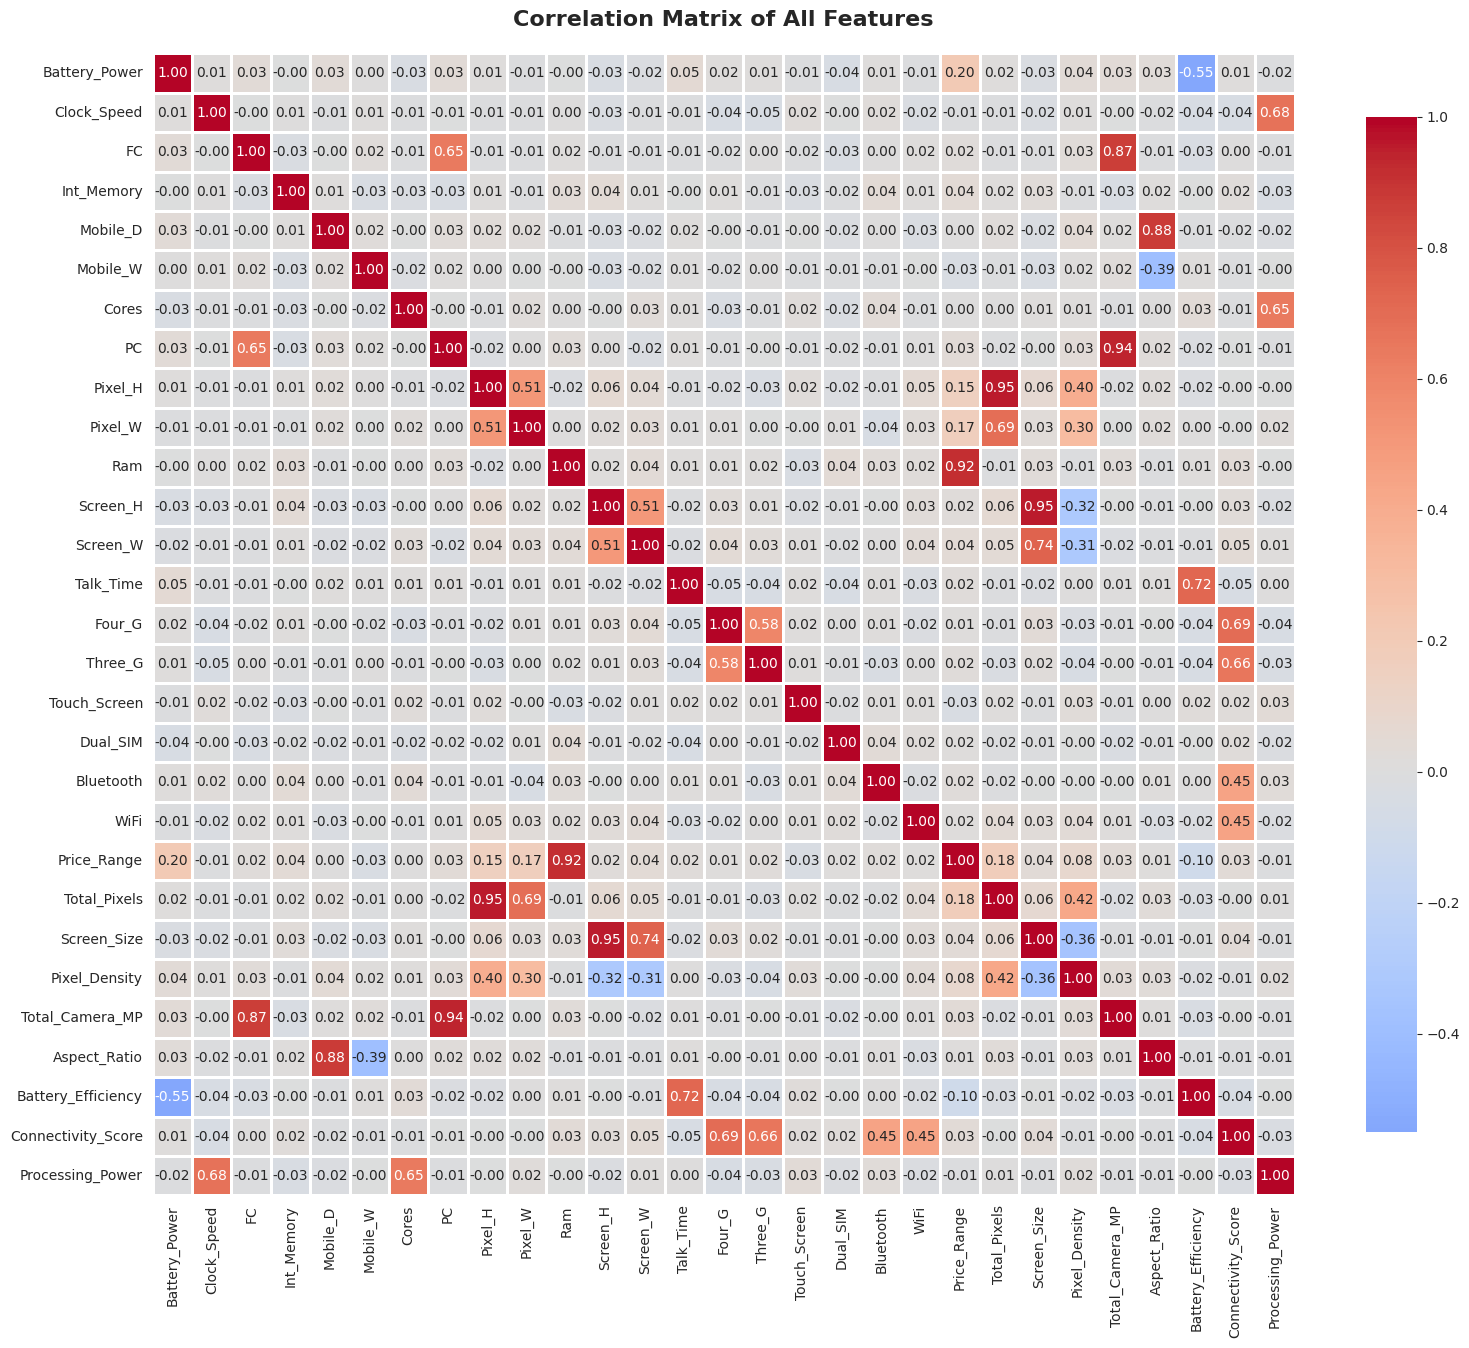

CORRELATION WITH TARGET VARIABLE (Price_Range)
Price_Range           1.000000
Ram                   0.917125
Battery_Power         0.200751
Total_Pixels          0.176477
Pixel_W               0.165789
Pixel_H               0.148832
Pixel_Density         0.080249
Int_Memory            0.044435
Screen_W              0.039219
Screen_Size           0.035787
Connectivity_Score    0.034527
PC                    0.033599
Total_Camera_MP       0.031862
Three_G               0.023611
Screen_H              0.022986
FC                    0.022491
Talk_Time             0.021859
Bluetooth             0.020573
WiFi                  0.018785
Dual_SIM              0.017444
Four_G                0.014772
Aspect_Ratio          0.012370
Cores                 0.004399
Mobile_D              0.000853
Clock_Speed          -0.006606
Processing_Power     -0.008290
Mobile_W             -0.030297
Touch_Screen         -0.030411
Battery_Efficiency   -0.098070
Name: Price_Range, dtype: float64


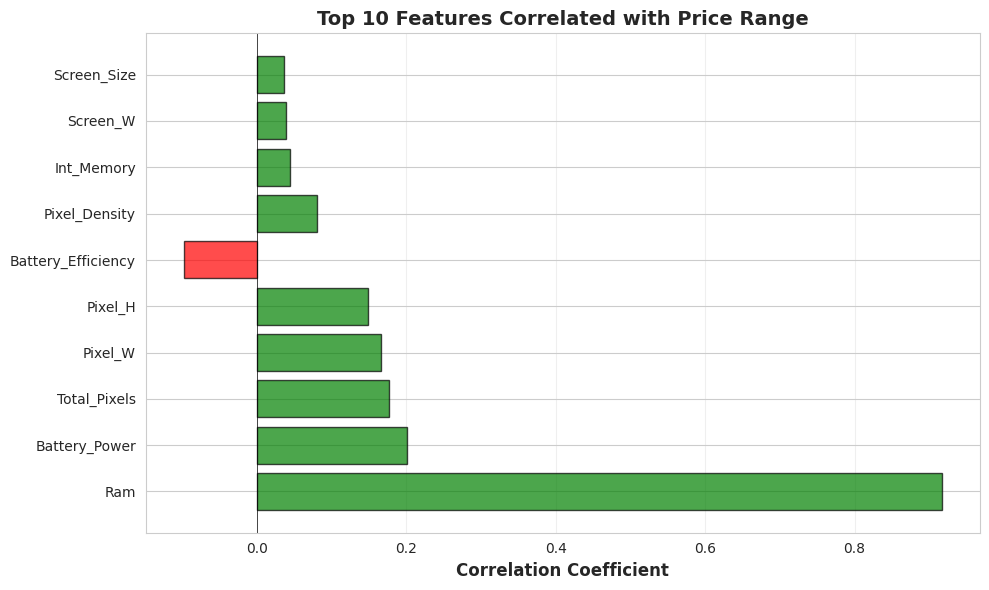

In [ ]:
# ======================================================================
# SECTION 8: CORRELATION ANALYSIS (AFTER FEATURE ENGINEERING)
# ======================================================================
plt.figure(figsize=(16, 14))
correlation_matrix = df_treated.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*60)
print("CORRELATION WITH TARGET VARIABLE (Price_Range)")
print("="*60)
target_corr = correlation_matrix['Price_Range'].sort_values(ascending=False)
print(target_corr)

# Visualize top correlations
plt.figure(figsize=(10, 6))
top_features = target_corr.abs().sort_values(ascending=False)[1:11]
colors = ['green' if x > 0 else 'red' for x in target_corr[top_features.index]]

plt.barh(range(len(top_features)), target_corr[top_features.index],
        color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
plt.title('Top 10 Features Correlated with Price Range', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()


FEATURE SELECTION

Total features before selection: 28

1. Correlation-based Feature Selection:
------------------------------------------------------------
Features with |correlation| > 0.05: 7

2. Statistical Test (ANOVA F-test):
------------------------------------------------------------

Top 15 Features by F-Score:
           Feature     F_Score
               Ram 3523.963244
     Battery_Power   31.615388
      Total_Pixels   26.163732
           Pixel_W   22.618892
           Pixel_H   19.560289
Battery_Efficiency    8.440961
     Pixel_Density    6.616320
          Mobile_W    3.599357
        Int_Memory    2.922996
       Screen_Size    2.684444
             Cores    2.625415
  Processing_Power    2.404728
          Screen_H    2.225984
      Aspect_Ratio    2.173999
          Screen_W    1.681883

3. Mutual Information:
------------------------------------------------------------

Top 15 Features by Mutual Information:
           Feature  MI_Score
               Ram  0.84587

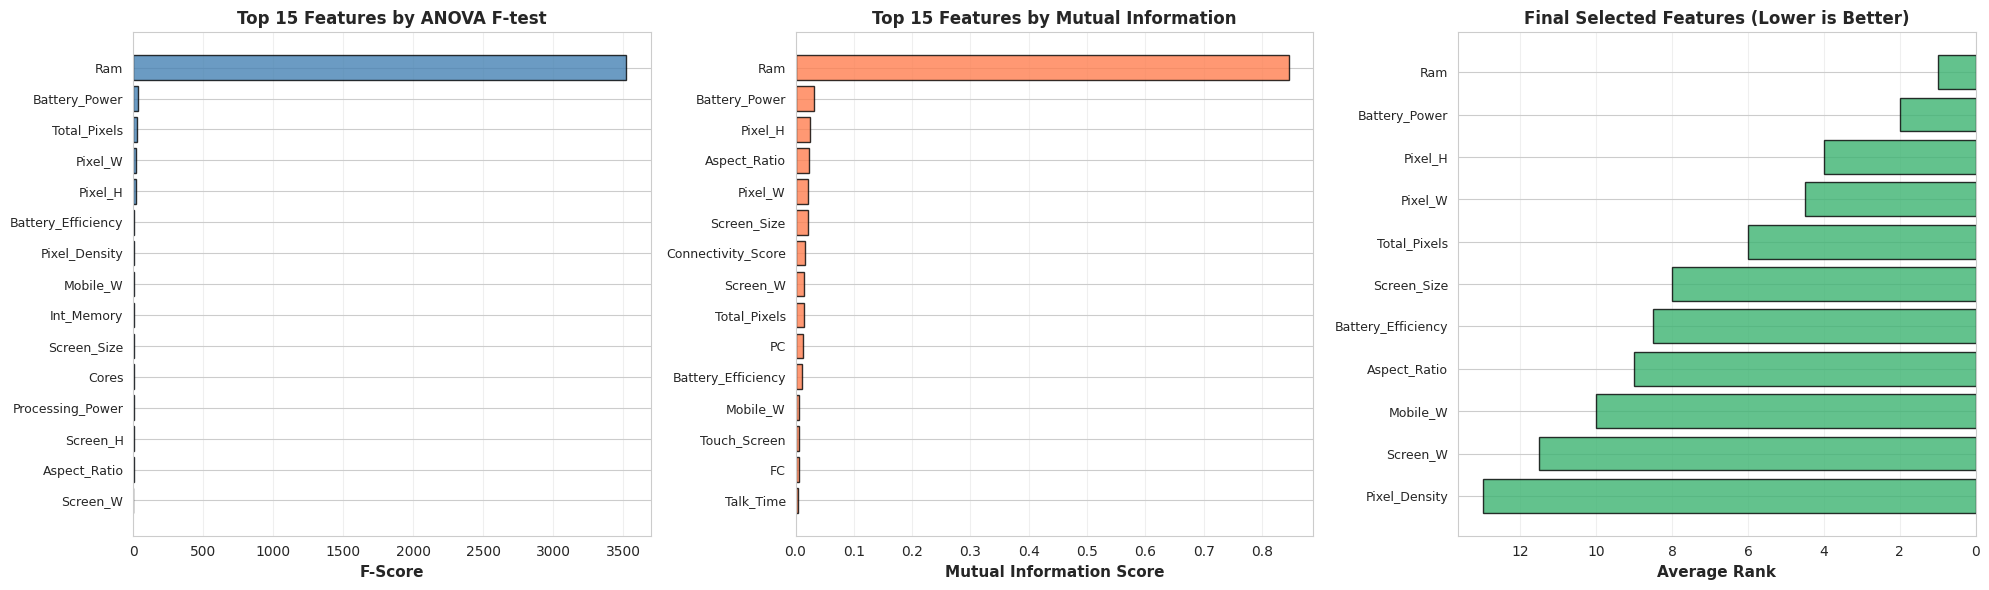


✓ Feature selection completed successfully!

Feature set reduced from 28 to 11 features
Reduction: 60.7%


In [ ]:
# ======================================================================
# SECTION 9: FEATURE SELECTION
# ======================================================================
print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

# Separate features and target
X_full = df_treated.drop('Price_Range', axis=1)
y = df_treated['Price_Range']

print(f"\nTotal features before selection: {X_full.shape[1]}")

# Method 1: Correlation-based filtering
print("\n1. Correlation-based Feature Selection:")
print("-" * 60)
correlation_threshold = 0.05
high_corr_features = target_corr[abs(target_corr) > correlation_threshold].index.tolist()
high_corr_features.remove('Price_Range')  # Remove target variable
print(f"Features with |correlation| > {correlation_threshold}: {len(high_corr_features)}")

# Method 2: Statistical test (ANOVA F-test)
print("\n2. Statistical Test (ANOVA F-test):")
print("-" * 60)
selector_f = SelectKBest(score_func=f_classif, k=15)
selector_f.fit(X_full, y)

# Get feature scores
f_scores = pd.DataFrame({
    'Feature': X_full.columns,
    'F_Score': selector_f.scores_
}).sort_values('F_Score', ascending=False)

print("\nTop 15 Features by F-Score:")
print(f_scores.head(15).to_string(index=False))

# Method 3: Mutual Information
print("\n3. Mutual Information:")
print("-" * 60)
mi_scores = mutual_info_classif(X_full, y, random_state=42)
mi_scores_df = pd.DataFrame({
    'Feature': X_full.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 15 Features by Mutual Information:")
print(mi_scores_df.head(15).to_string(index=False))

# Combined approach: Select features that appear in top rankings
top_k = 15
top_f_features = set(f_scores.head(top_k)['Feature'].tolist())
top_mi_features = set(mi_scores_df.head(top_k)['Feature'].tolist())
top_corr_features = set(high_corr_features[:top_k])

# Features appearing in at least 2 out of 3 methods
selected_features = list((top_f_features & top_mi_features) |
                        (top_f_features & top_corr_features) |
                        (top_mi_features & top_corr_features))

print("\n" + "="*60)
print("FINAL SELECTED FEATURES (CONSENSUS APPROACH)")
print("="*60)
print(f"Number of selected features: {len(selected_features)}")
print("\nSelected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Visualize feature selection results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: F-Scores
top_15_f = f_scores.head(15)
axes[0].barh(range(len(top_15_f)), top_15_f['F_Score'],
            color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(top_15_f)))
axes[0].set_yticklabels(top_15_f['Feature'], fontsize=9)
axes[0].set_xlabel('F-Score', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Features by ANOVA F-test', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Mutual Information
top_15_mi = mi_scores_df.head(15)
axes[1].barh(range(len(top_15_mi)), top_15_mi['MI_Score'],
            color='coral', alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(top_15_mi)))
axes[1].set_yticklabels(top_15_mi['Feature'], fontsize=9)
axes[1].set_xlabel('Mutual Information Score', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Features by Mutual Information', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Plot 3: Selected features with their average ranking
selected_ranking = []
for feat in selected_features:
    f_rank = list(f_scores['Feature']).index(feat) + 1 if feat in f_scores['Feature'].values else 100
    mi_rank = list(mi_scores_df['Feature']).index(feat) + 1 if feat in mi_scores_df['Feature'].values else 100
    avg_rank = (f_rank + mi_rank) / 2
    selected_ranking.append({'Feature': feat, 'Avg_Rank': avg_rank})

selected_df = pd.DataFrame(selected_ranking).sort_values('Avg_Rank')
axes[2].barh(range(len(selected_df)), selected_df['Avg_Rank'],
            color='mediumseagreen', alpha=0.8, edgecolor='black')
axes[2].set_yticks(range(len(selected_df)))
axes[2].set_yticklabels(selected_df['Feature'], fontsize=9)
axes[2].set_xlabel('Average Rank', fontsize=11, fontweight='bold')
axes[2].set_title('Final Selected Features (Lower is Better)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].invert_xaxis()
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_selection_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature selection completed successfully!")

# Create the final feature set
X_selected = X_full[selected_features]

print("\n" + "="*60)
print(f"Feature set reduced from {X_full.shape[1]} to {X_selected.shape[1]} features")
print(f"Reduction: {((X_full.shape[1] - X_selected.shape[1]) / X_full.shape[1] * 100):.1f}%")
print("="*60)

In [ ]:
# ======================================================================
# SECTION 10: DATA PREPARATION (USING SELECTED FEATURES)
# ======================================================================
print("\n" + "="*60)
print("DATA PREPARATION FOR MODELING")
print("="*60)

X = X_selected.copy()
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set size: {X_train.shape[0]} samples ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({(len(X_test)/len(X))*100:.1f}%)")

print("\n" + "="*60)
print("TARGET DISTRIBUTION IN TRAIN SET")
print("="*60)
print(y_train.value_counts().sort_index())
print(f"\nProportions:\n{y_train.value_counts(normalize=True).sort_index() * 100}")

print("\n" + "="*60)
print("TARGET DISTRIBUTION IN TEST SET")
print("="*60)
print(y_test.value_counts().sort_index())
print(f"\nProportions:\n{y_test.value_counts(normalize=True).sort_index() * 100}")

print("\n✓ Stratified split ensures balanced class distribution in both sets!")


DATA PREPARATION FOR MODELING

Feature matrix shape: (2000, 11)
Target vector shape: (2000,)

TRAIN-TEST SPLIT
Training set size: 1600 samples (80.0%)
Test set size: 400 samples (20.0%)

TARGET DISTRIBUTION IN TRAIN SET
Price_Range
0    400
1    400
2    400
3    400
Name: count, dtype: int64

Proportions:
Price_Range
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

TARGET DISTRIBUTION IN TEST SET
Price_Range
0    100
1    100
2    100
3    100
Name: count, dtype: int64

Proportions:
Price_Range
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

✓ Stratified split ensures balanced class distribution in both sets!



FEATURE SCALING
Performing final data quality checks...
✓ Data quality checks passed!

Standardization applied (mean=0, std=1)

Before scaling - Training data statistics:


,Mobile_W,Total_Pixels,Battery_Power,Pixel_Density,Pixel_H,Battery_Efficiency,Pixel_W,Screen_W,Screen_Size,Aspect_Ratio,Ram
mean,140.09,900719.25,1236.66,24692.05,646.32,10.11,1246.49,5.77,13.95,0.0,2125.06
std,35.27,821315.46,437.87,49795.02,442.42,6.63,428.92,4.37,5.14,0.0,1085.02



After scaling - Training data statistics:


,Mobile_W,Total_Pixels,Battery_Power,Pixel_Density,Pixel_H,Battery_Efficiency,Pixel_W,Screen_W,Screen_Size,Aspect_Ratio,Ram
mean,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


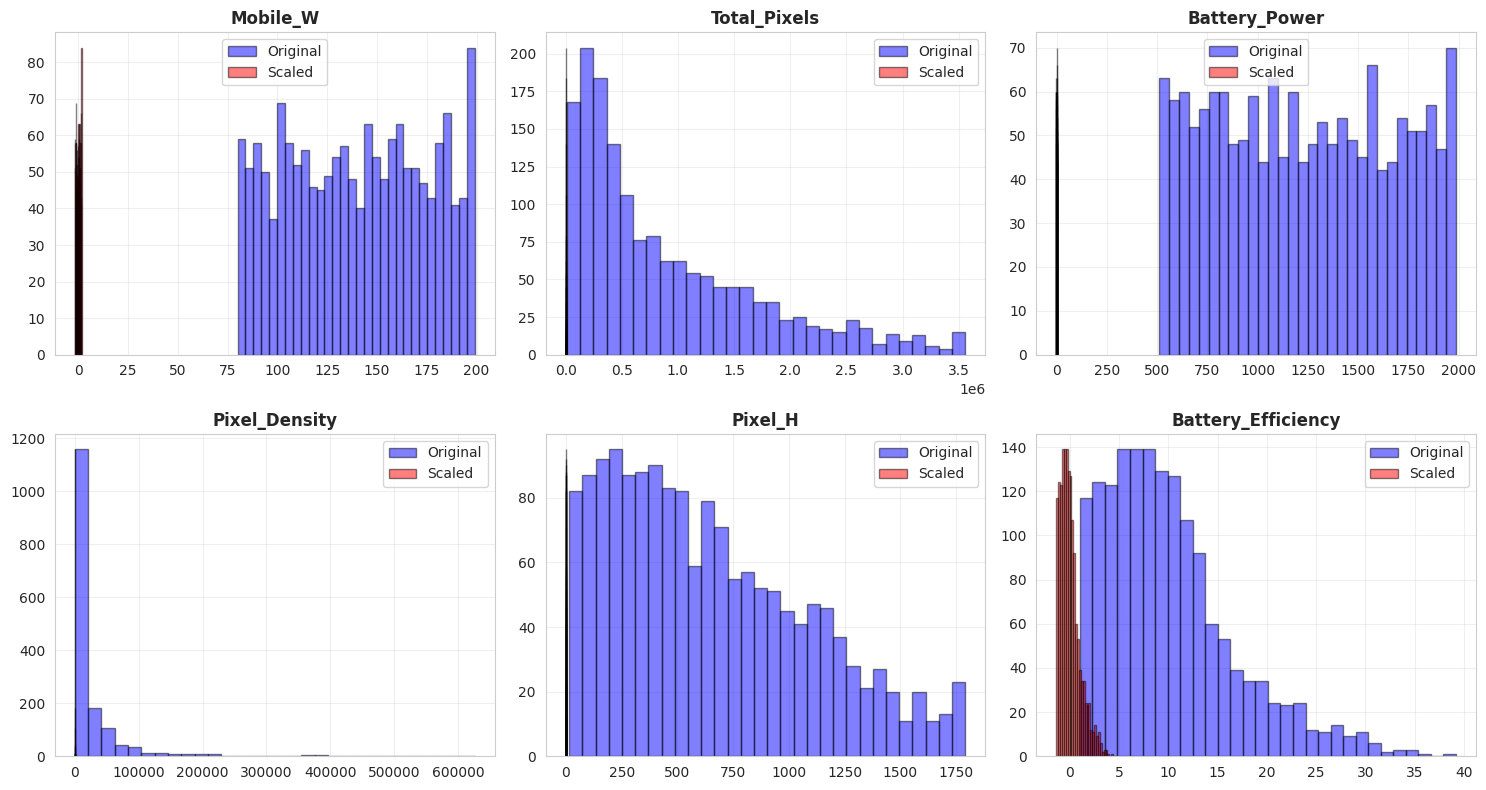


✓ Feature scaling completed successfully!


In [ ]:
# ======================================================================
# SECTION 11: FEATURE SCALING
# ======================================================================
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

print("Performing final data quality checks...")
inf_count = np.isinf(X_train).sum().sum()
nan_count = np.isnan(X_train).sum().sum()

if inf_count > 0:
    print(f"⚠ Warning: Found {inf_count} infinite values. Replacing with 0...")
    X_train = X_train.replace([np.inf, -np.inf], 0)
    X_test = X_test.replace([np.inf, -np.inf], 0)

if nan_count > 0:
    print(f"⚠ Warning: Found {nan_count} NaN values. Filling with 0...")
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

print("✓ Data quality checks passed!")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nStandardization applied (mean=0, std=1)")
print("\nBefore scaling - Training data statistics:")
display(X_train.describe().loc[['mean', 'std']].round(2))
print("\nAfter scaling - Training data statistics:")
display(X_train_scaled_df.describe().loc[['mean', 'std']].round(2))

# Visualize scaling effect for selected features
sample_size = min(6, len(selected_features))
sample_features = selected_features[:sample_size]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(sample_features):
    if idx < len(axes):
        axes[idx].hist(X_train[feature], bins=30, alpha=0.5, label='Original',
                      color='blue', edgecolor='black')
        axes[idx].hist(X_train_scaled_df[feature], bins=30, alpha=0.5, label='Scaled',
                      color='red', edgecolor='black')
        axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

# Remove unused subplots
for idx in range(len(sample_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature scaling completed successfully!")


MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression...
✓ Training completed!

STEP 1: TRAINING SET PERFORMANCE
Training Accuracy: 0.9706 (97.06%)
Training Log Loss: 0.1940

STEP 2: CROSS-VALIDATION (5-Fold on Training Data)
CV Accuracy Scores: [0.959375 0.959375 0.95625  0.965625 0.95625 ]
Mean CV Accuracy: 0.9594 (+/- 0.0068)
CV Log Loss Scores: [0.21320517 0.2251878  0.22075087 0.21719953 0.20719375]
Mean CV Log Loss: 0.2167 (+/- 0.0124)

✓ Cross-validation completed - Model shows good generalization
  Training Accuracy: 0.9706
  CV Mean Accuracy: 0.9594
  Difference: 0.0112

STEP 3: FINAL TEST SET EVALUATION (Holdout Data)
Test Accuracy: 0.9775 (97.75%)
Test Log Loss: 0.1829

📊 Performance Summary:
  Training Accuracy: 0.9706 | Log Loss: 0.1940
  Cross-Val Accuracy: 0.9594 | Log Loss: 0.2167
  Test Accuracy: 0.9775 | Log Loss: 0.1829
  Train-Test Accuracy Gap: -0.69%
  Train-Test Log Loss Gap: 0.0112

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-sco

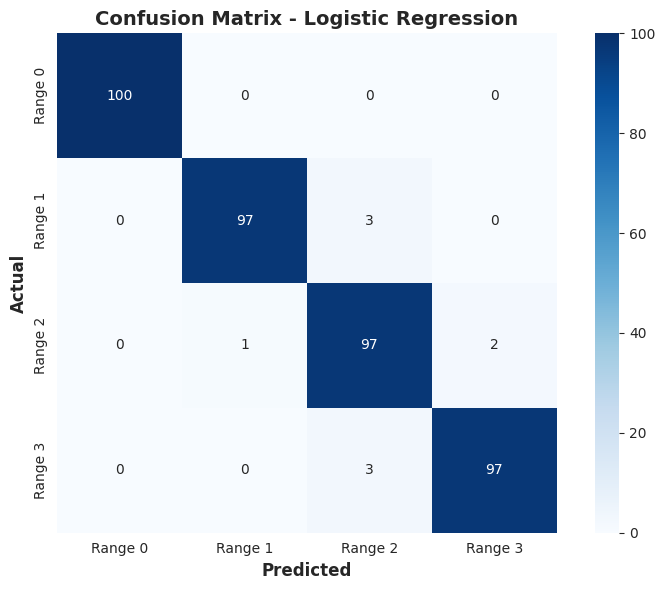


STEP 4: LEARNING CURVES ANALYSIS
Generating learning curves for Logistic Regression...


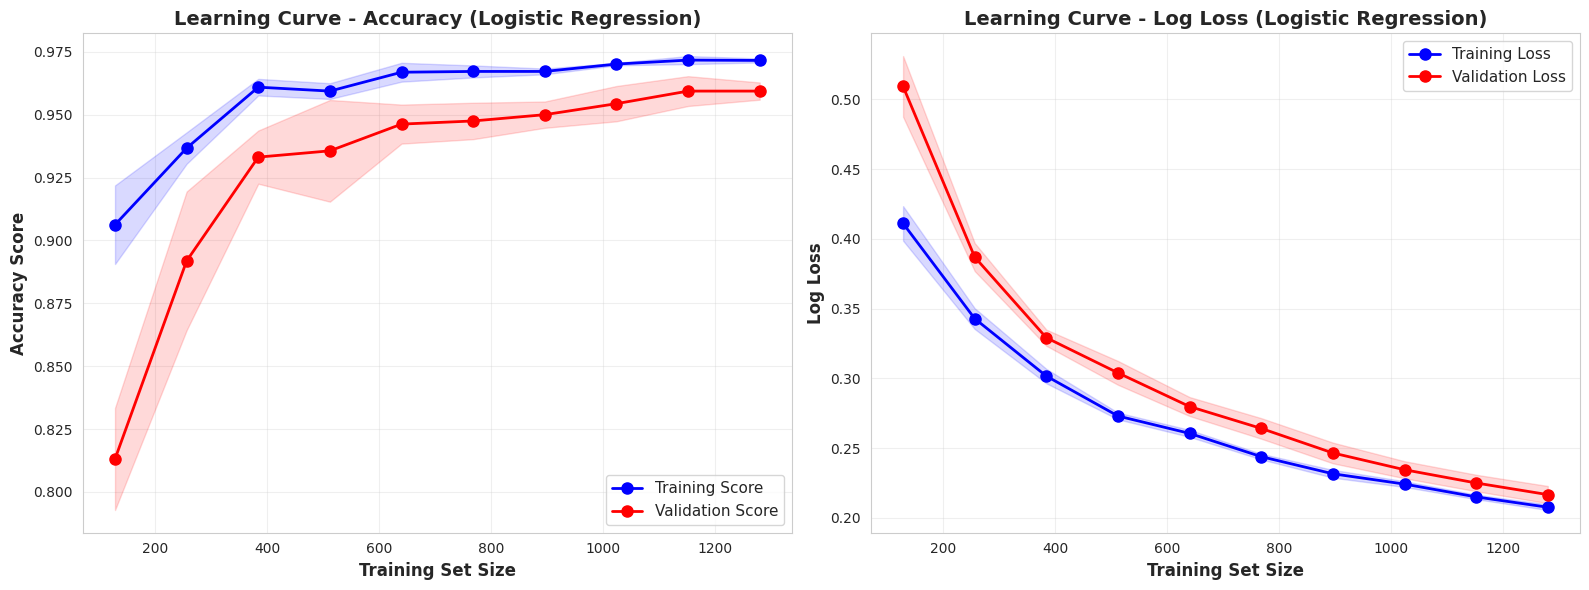

✓ Learning curves generated!

Final Training Accuracy: 0.9716 | Log Loss: 0.2077
Final Validation Accuracy: 0.9594 | Log Loss: 0.2167
Accuracy variance: 0.0122
Log Loss variance: 0.0090

✓ LOGISTIC REGRESSION EVALUATION COMPLETE


In [ ]:
# ======================================================================
# SECTION 12: MODEL 1 - LOGISTIC REGRESSION
# ======================================================================
print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')

print("\nTraining Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)
print("✓ Training completed!")

# STEP 1: Training Performance
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_train_proba_lr = lr_model.predict_proba(X_train_scaled)
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
train_logloss_lr = log_loss(y_train, y_train_proba_lr)

print("\n" + "="*70)
print("STEP 1: TRAINING SET PERFORMANCE")
print("="*70)
print(f"Training Accuracy: {train_accuracy_lr:.4f} ({train_accuracy_lr*100:.2f}%)")
print(f"Training Log Loss: {train_logloss_lr:.4f}")

# STEP 2: Cross-Validation
print("\n" + "="*70)
print("STEP 2: CROSS-VALIDATION (5-Fold on Training Data)")
print("="*70)
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_logloss_lr = -cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_log_loss')

print(f"CV Accuracy Scores: {cv_scores_lr}")
print(f"Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")
print(f"CV Log Loss Scores: {cv_logloss_lr}")
print(f"Mean CV Log Loss: {cv_logloss_lr.mean():.4f} (+/- {cv_logloss_lr.std() * 2:.4f})")

print("\n✓ Cross-validation completed - Model shows good generalization")
print(f"  Training Accuracy: {train_accuracy_lr:.4f}")
print(f"  CV Mean Accuracy: {cv_scores_lr.mean():.4f}")
print(f"  Difference: {abs(train_accuracy_lr - cv_scores_lr.mean()):.4f}")

# STEP 3: Final Test Evaluation
print("\n" + "="*70)
print("STEP 3: FINAL TEST SET EVALUATION (Holdout Data)")
print("="*70)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
test_logloss_lr = log_loss(y_test, y_test_proba_lr)

print(f"Test Accuracy: {test_accuracy_lr:.4f} ({test_accuracy_lr*100:.2f}%)")
print(f"Test Log Loss: {test_logloss_lr:.4f}")

print(f"\n📊 Performance Summary:")
print(f"  Training Accuracy: {train_accuracy_lr:.4f} | Log Loss: {train_logloss_lr:.4f}")
print(f"  Cross-Val Accuracy: {cv_scores_lr.mean():.4f} | Log Loss: {cv_logloss_lr.mean():.4f}")
print(f"  Test Accuracy: {test_accuracy_lr:.4f} | Log Loss: {test_logloss_lr:.4f}")
print(f"  Train-Test Accuracy Gap: {(train_accuracy_lr - test_accuracy_lr)*100:.2f}%")
print(f"  Train-Test Log Loss Gap: {(train_logloss_lr - test_logloss_lr):.4f}")

print("\n" + "="*70)
print("CLASSIFICATION REPORT (Test Set)")
print("="*70)
print(classification_report(y_test, y_test_pred_lr,
                          target_names=['Range 0', 'Range 1', 'Range 2', 'Range 3']))

print("\n" + "="*70)
print("CONFUSION MATRIX (Test Set)")
print("="*70)
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print(cm_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', square=True,
           xticklabels=['Range 0', 'Range 1', 'Range 2', 'Range 3'],
           yticklabels=['Range 0', 'Range 1', 'Range 2', 'Range 3'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 4: Learning Curves (Accuracy & Log Loss)
print("\n" + "="*70)
print("STEP 4: LEARNING CURVES ANALYSIS")
print("="*70)
print("Generating learning curves for Logistic Regression...")

train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Log Loss Learning Curve
train_sizes_loss, train_scores_loss, val_scores_loss = learning_curve(
    lr_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)

train_mean_loss = -np.mean(train_scores_loss, axis=1)  # Convert to positive
train_std_loss = np.std(train_scores_loss, axis=1)
val_mean_loss = -np.mean(val_scores_loss, axis=1)  # Convert to positive
val_std_loss = np.std(val_scores_loss, axis=1)

# Create dual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Learning Curve
axes[0].plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score',
            linewidth=2, markersize=8)
axes[0].plot(train_sizes, val_mean, 'o-', color='red', label='Validation Score',
            linewidth=2, markersize=8)
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='blue')
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='red')
axes[0].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[0].set_title('Learning Curve - Accuracy (Logistic Regression)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Log Loss Learning Curve
axes[1].plot(train_sizes_loss, train_mean_loss, 'o-', color='blue', label='Training Loss',
            linewidth=2, markersize=8)
axes[1].plot(train_sizes_loss, val_mean_loss, 'o-', color='red', label='Validation Loss',
            linewidth=2, markersize=8)
axes[1].fill_between(train_sizes_loss, train_mean_loss - train_std_loss,
                     train_mean_loss + train_std_loss, alpha=0.15, color='blue')
axes[1].fill_between(train_sizes_loss, val_mean_loss - val_std_loss,
                     val_mean_loss + val_std_loss, alpha=0.15, color='red')
axes[1].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Learning Curve - Log Loss (Logistic Regression)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_lr_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Learning curves generated!")
print(f"\nFinal Training Accuracy: {train_mean[-1]:.4f} | Log Loss: {train_mean_loss[-1]:.4f}")
print(f"Final Validation Accuracy: {val_mean[-1]:.4f} | Log Loss: {val_mean_loss[-1]:.4f}")
print(f"Accuracy variance: {abs(train_mean[-1] - val_mean[-1]):.4f}")
print(f"Log Loss variance: {abs(train_mean_loss[-1] - val_mean_loss[-1]):.4f}")

print("\n" + "="*70)
print("✓ LOGISTIC REGRESSION EVALUATION COMPLETE")
print("="*70)


MODEL 2: XGBOOST CLASSIFIER

Training XGBoost with 400 estimators...
✓ Training completed!

STEP 1: TRAINING SET PERFORMANCE
Training Accuracy: 1.0000 (100.00%)
Training Log Loss: 0.0353

STEP 2: CROSS-VALIDATION (5-Fold on Training Data)
CV Accuracy Scores: [0.9125   0.896875 0.909375 0.88125  0.921875]
Mean CV Accuracy: 0.9044 (+/- 0.0281)
CV Log Loss Scores: [0.19858266 0.23701219 0.22800075 0.26259677 0.21092884]
Mean CV Log Loss: 0.2274 (+/- 0.0441)

✓ Cross-validation completed
  Training Accuracy: 1.0000
  CV Mean Accuracy: 0.9044
  Difference: 0.0956

STEP 3: FINAL TEST SET EVALUATION (Holdout Data)
Test Accuracy: 0.9400 (94.00%)
Test Log Loss: 0.1532

📊 Performance Summary:
  Training Accuracy: 1.0000 | Log Loss: 0.0353
  Cross-Val Accuracy: 0.9044 | Log Loss: 0.2274
  Test Accuracy: 0.9400 | Log Loss: 0.1532
  Train-Test Accuracy Gap: 6.00%
  Train-Test Log Loss Gap: -0.1179

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

     Range 0

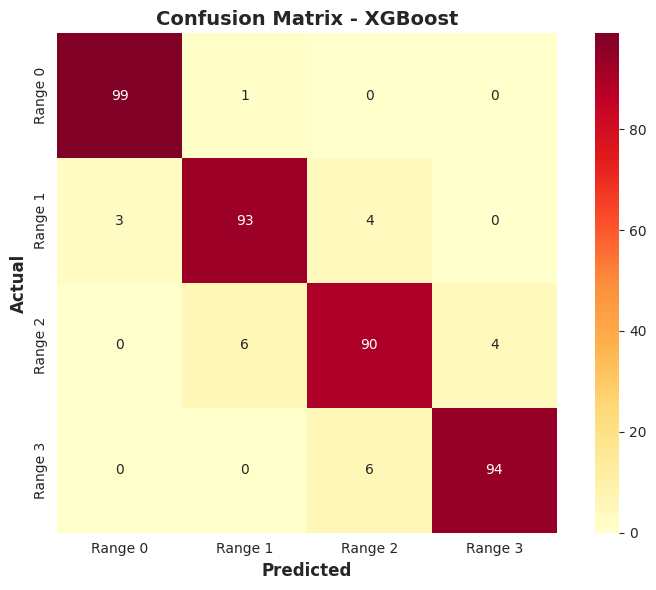


STEP 4: LEARNING CURVES ANALYSIS
Generating learning curves for XGBoost...


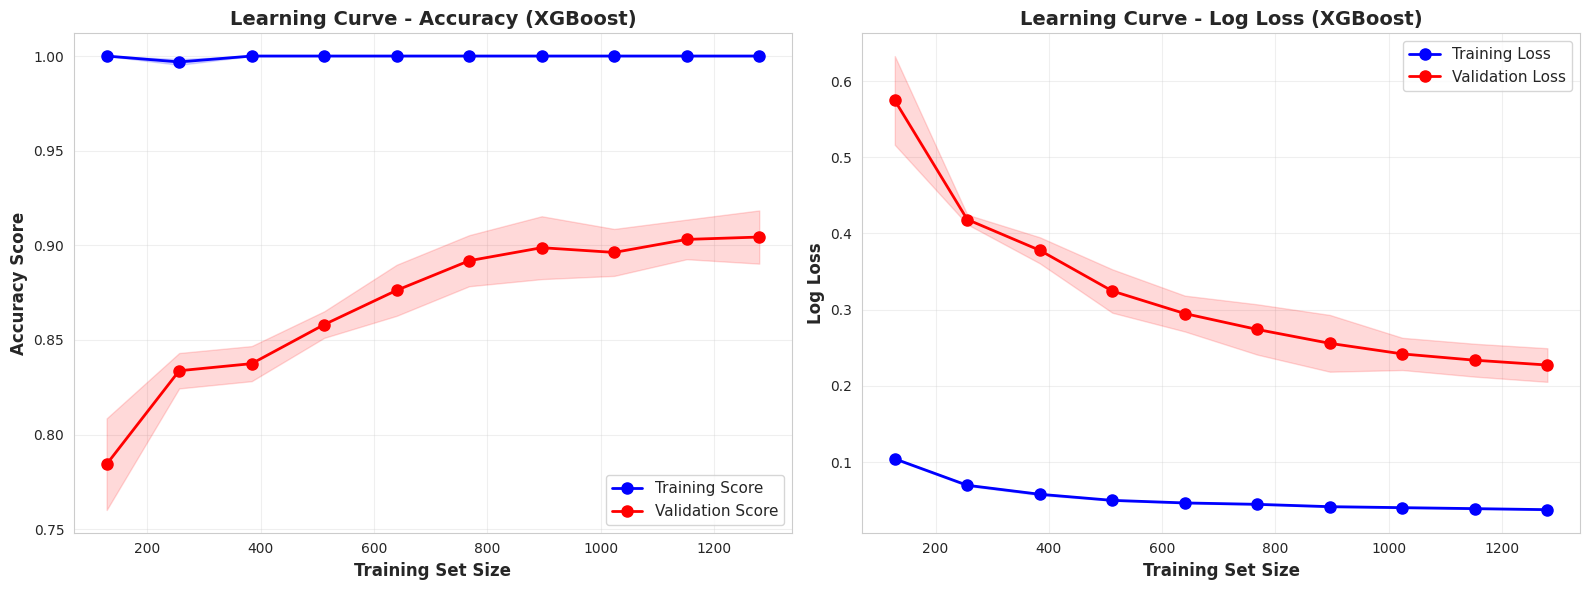

✓ Learning curves generated!

Final Training Accuracy: 1.0000 | Log Loss: 0.0376
Final Validation Accuracy: 0.9044 | Log Loss: 0.2274
Accuracy variance: 0.0956
Log Loss variance: 0.1898

✓ XGBOOST EVALUATION COMPLETE


In [ ]:
# ======================================================================
# SECTION 13: MODEL 2 - XGBOOST
# ======================================================================
print("\n" + "="*70)
print("MODEL 2: XGBOOST CLASSIFIER")
print("="*70)

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.2,
    gamma=0.2,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

print("\nTraining XGBoost with 400 estimators...")
xgb_model.fit(X_train, y_train)
print("✓ Training completed!")

# STEP 1: Training Performance
y_train_pred_xgb = xgb_model.predict(X_train)
y_train_proba_xgb = xgb_model.predict_proba(X_train)
train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
train_logloss_xgb = log_loss(y_train, y_train_proba_xgb)

print("\n" + "="*70)
print("STEP 1: TRAINING SET PERFORMANCE")
print("="*70)
print(f"Training Accuracy: {train_accuracy_xgb:.4f} ({train_accuracy_xgb*100:.2f}%)")
print(f"Training Log Loss: {train_logloss_xgb:.4f}")

# STEP 2: Cross-Validation
print("\n" + "="*70)
print("STEP 2: CROSS-VALIDATION (5-Fold on Training Data)")
print("="*70)
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
cv_logloss_xgb = -cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_log_loss')

print(f"CV Accuracy Scores: {cv_scores_xgb}")
print(f"Mean CV Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")
print(f"CV Log Loss Scores: {cv_logloss_xgb}")
print(f"Mean CV Log Loss: {cv_logloss_xgb.mean():.4f} (+/- {cv_logloss_xgb.std() * 2:.4f})")

print("\n✓ Cross-validation completed")
print(f"  Training Accuracy: {train_accuracy_xgb:.4f}")
print(f"  CV Mean Accuracy: {cv_scores_xgb.mean():.4f}")
print(f"  Difference: {abs(train_accuracy_xgb - cv_scores_xgb.mean()):.4f}")

# STEP 3: Final Test Evaluation
print("\n" + "="*70)
print("STEP 3: FINAL TEST SET EVALUATION (Holdout Data)")
print("="*70)
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_proba_xgb = xgb_model.predict_proba(X_test)
test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_logloss_xgb = log_loss(y_test, y_test_proba_xgb)

print(f"Test Accuracy: {test_accuracy_xgb:.4f} ({test_accuracy_xgb*100:.2f}%)")
print(f"Test Log Loss: {test_logloss_xgb:.4f}")

print(f"\n📊 Performance Summary:")
print(f"  Training Accuracy: {train_accuracy_xgb:.4f} | Log Loss: {train_logloss_xgb:.4f}")
print(f"  Cross-Val Accuracy: {cv_scores_xgb.mean():.4f} | Log Loss: {cv_logloss_xgb.mean():.4f}")
print(f"  Test Accuracy: {test_accuracy_xgb:.4f} | Log Loss: {test_logloss_xgb:.4f}")
print(f"  Train-Test Accuracy Gap: {(train_accuracy_xgb - test_accuracy_xgb)*100:.2f}%")
print(f"  Train-Test Log Loss Gap: {(train_logloss_xgb - test_logloss_xgb):.4f}")

print("\n" + "="*70)
print("CLASSIFICATION REPORT (Test Set)")
print("="*70)
print(classification_report(y_test, y_test_pred_xgb,
                          target_names=['Range 0', 'Range 1', 'Range 2', 'Range 3']))

print("\n" + "="*70)
print("CONFUSION MATRIX (Test Set)")
print("="*70)
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
print(cm_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd', square=True,
           xticklabels=['Range 0', 'Range 1', 'Range 2', 'Range 3'],
           yticklabels=['Range 0', 'Range 1', 'Range 2', 'Range 3'])
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 4: Learning Curves (Accuracy & Log Loss)
print("\n" + "="*70)
print("STEP 4: LEARNING CURVES ANALYSIS")
print("="*70)
print("Generating learning curves for XGBoost...")

train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    xgb_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)

train_mean_xgb = np.mean(train_scores_xgb, axis=1)
train_std_xgb = np.std(train_scores_xgb, axis=1)
val_mean_xgb = np.mean(val_scores_xgb, axis=1)
val_std_xgb = np.std(val_scores_xgb, axis=1)

# Log Loss Learning Curve
train_sizes_loss_xgb, train_scores_loss_xgb, val_scores_loss_xgb = learning_curve(
    xgb_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)

train_mean_loss_xgb = -np.mean(train_scores_loss_xgb, axis=1)
train_std_loss_xgb = np.std(train_scores_loss_xgb, axis=1)
val_mean_loss_xgb = -np.mean(val_scores_loss_xgb, axis=1)
val_std_loss_xgb = np.std(val_scores_loss_xgb, axis=1)

# Create dual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Learning Curve
axes[0].plot(train_sizes_xgb, train_mean_xgb, 'o-', color='blue', label='Training Score',
            linewidth=2, markersize=8)
axes[0].plot(train_sizes_xgb, val_mean_xgb, 'o-', color='red', label='Validation Score',
            linewidth=2, markersize=8)
axes[0].fill_between(train_sizes_xgb, train_mean_xgb - train_std_xgb,
                     train_mean_xgb + train_std_xgb, alpha=0.15, color='blue')
axes[0].fill_between(train_sizes_xgb, val_mean_xgb - val_std_xgb,
                     val_mean_xgb + val_std_xgb, alpha=0.15, color='red')
axes[0].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[0].set_title('Learning Curve - Accuracy (XGBoost)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Log Loss Learning Curve
axes[1].plot(train_sizes_loss_xgb, train_mean_loss_xgb, 'o-', color='blue', label='Training Loss',
            linewidth=2, markersize=8)
axes[1].plot(train_sizes_loss_xgb, val_mean_loss_xgb, 'o-', color='red', label='Validation Loss',
            linewidth=2, markersize=8)
axes[1].fill_between(train_sizes_loss_xgb, train_mean_loss_xgb - train_std_loss_xgb,
                     train_mean_loss_xgb + train_std_loss_xgb, alpha=0.15, color='blue')
axes[1].fill_between(train_sizes_loss_xgb, val_mean_loss_xgb - val_std_loss_xgb,
                     val_mean_loss_xgb + val_std_loss_xgb, alpha=0.15, color='red')
axes[1].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Learning Curve - Log Loss (XGBoost)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_xgb_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Learning curves generated!")
print(f"\nFinal Training Accuracy: {train_mean_xgb[-1]:.4f} | Log Loss: {train_mean_loss_xgb[-1]:.4f}")
print(f"Final Validation Accuracy: {val_mean_xgb[-1]:.4f} | Log Loss: {val_mean_loss_xgb[-1]:.4f}")
print(f"Accuracy variance: {abs(train_mean_xgb[-1] - val_mean_xgb[-1]):.4f}")
print(f"Log Loss variance: {abs(train_mean_loss_xgb[-1] - val_mean_loss_xgb[-1]):.4f}")

print("\n" + "="*70)
print("✓ XGBOOST EVALUATION COMPLETE")
print("="*70)


COMPREHENSIVE MODEL COMPARISON
              Model  Training Accuracy  Test Accuracy  CV Mean Accuracy  CV Std Dev  Training Log Loss  Test Log Loss  CV Mean Log Loss  Accuracy Gap  Log Loss Gap
Logistic Regression           0.970625         0.9775          0.959375    0.003423           0.194029       0.182869          0.216707     -0.006875      0.011160
            XGBoost           1.000000         0.9400          0.904375    0.014059           0.035303       0.153184          0.227424      0.060000     -0.117881


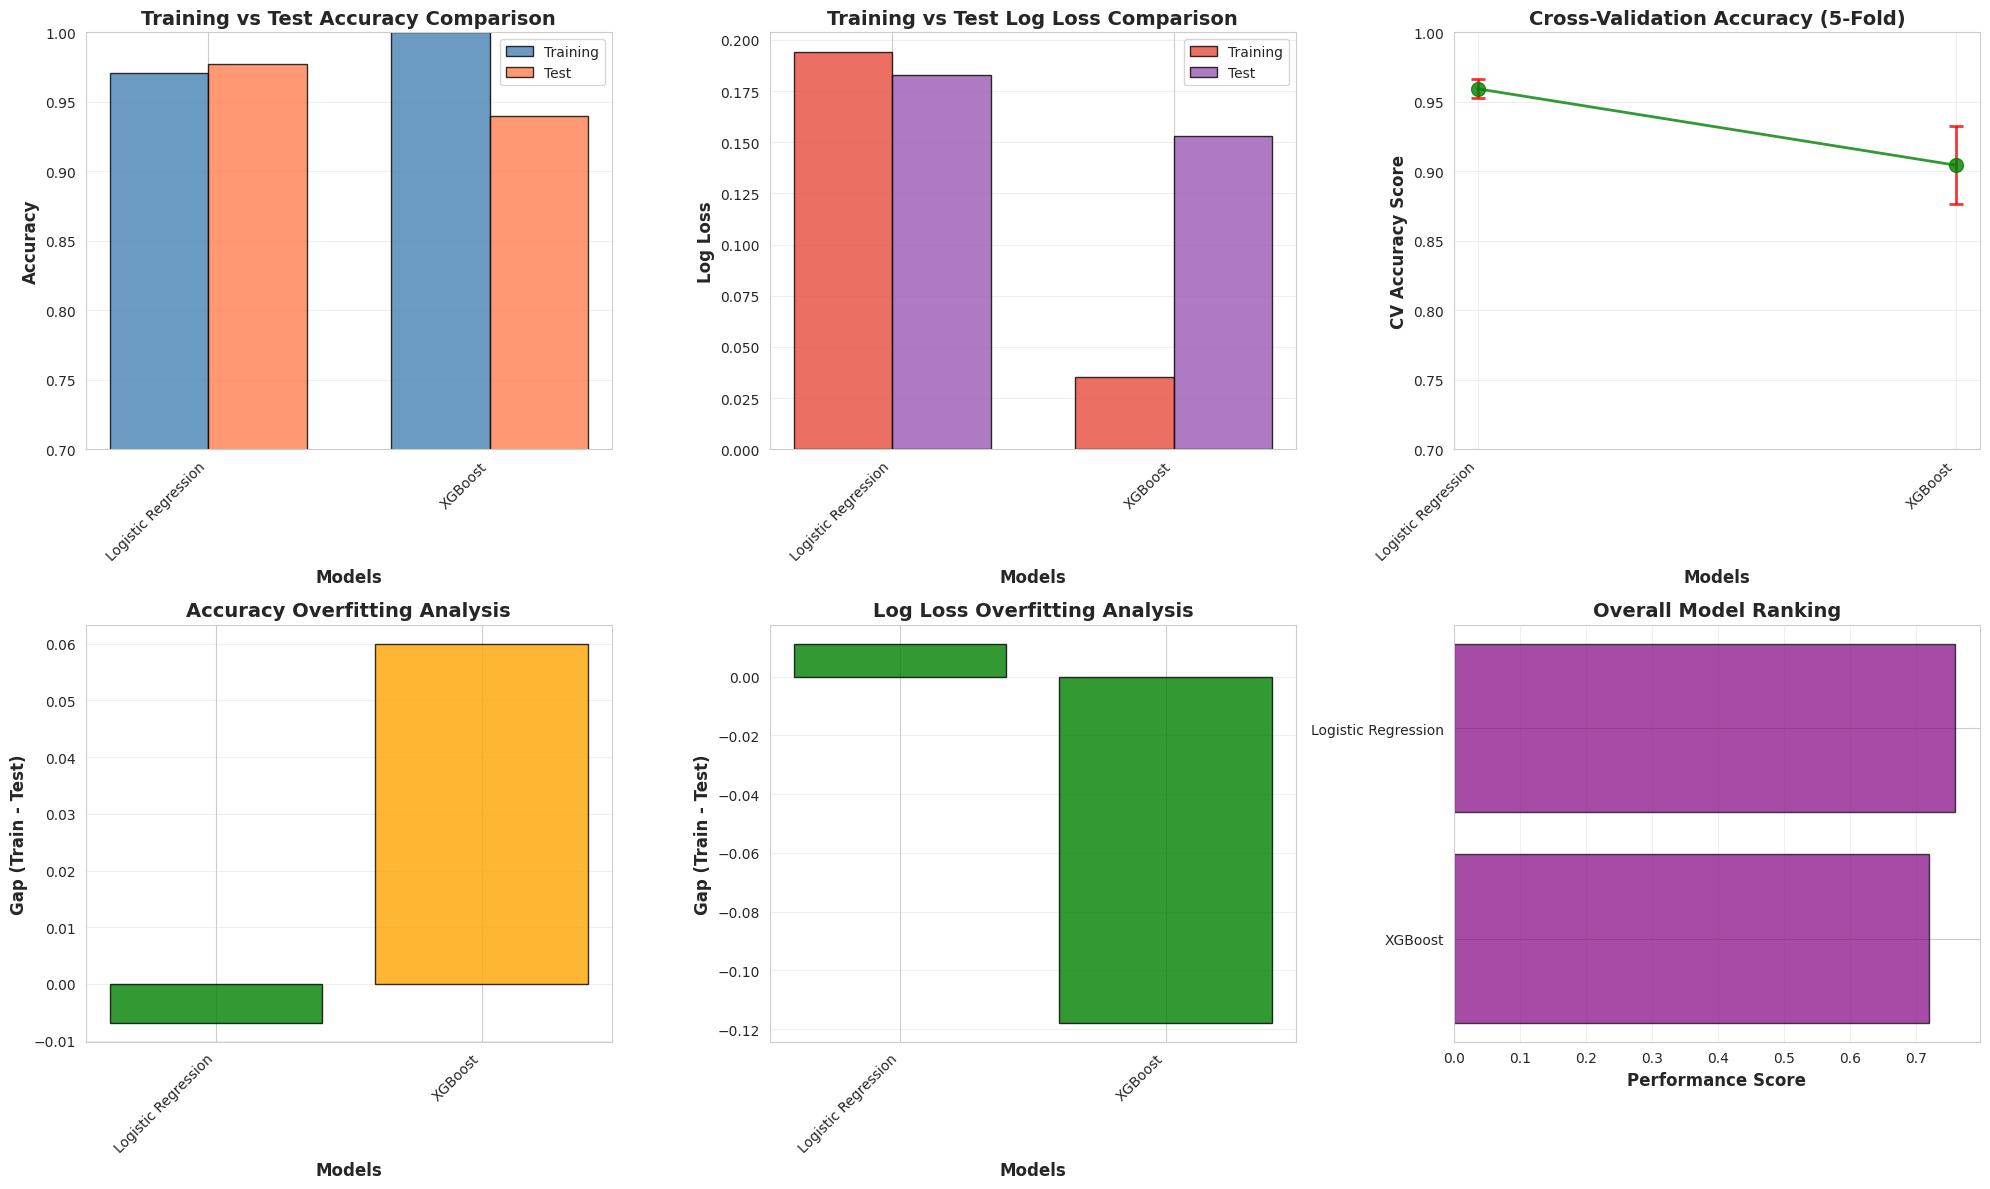


BEST MODEL IDENTIFIED
Model: Logistic Regression
Test Accuracy: 0.9775 (97.75%)
Test Log Loss: 0.1829

Creating combined learning curves visualization...


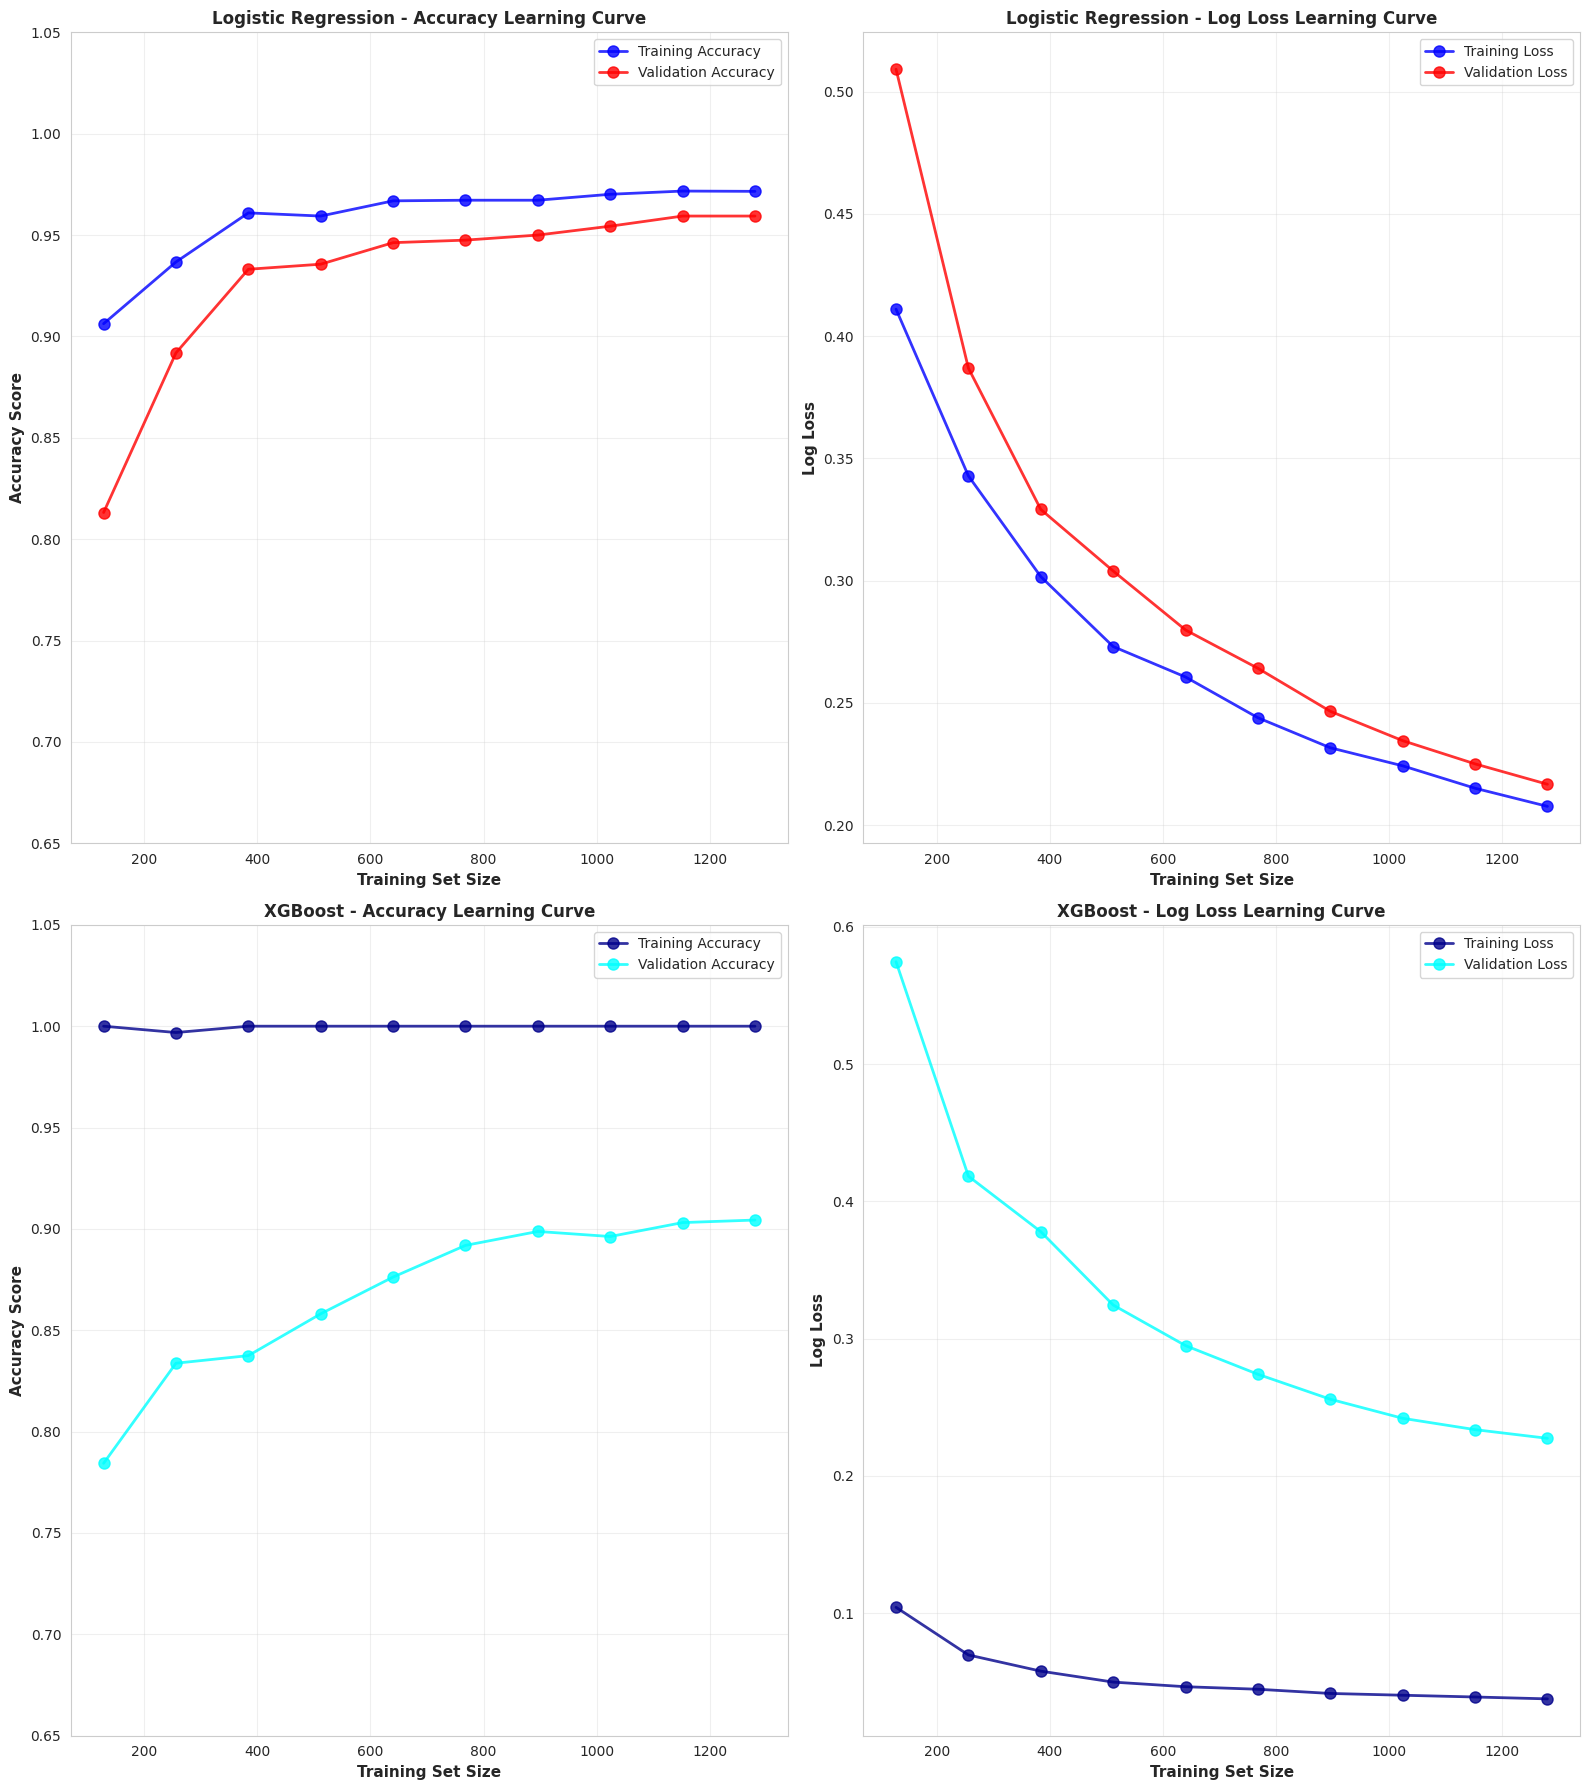

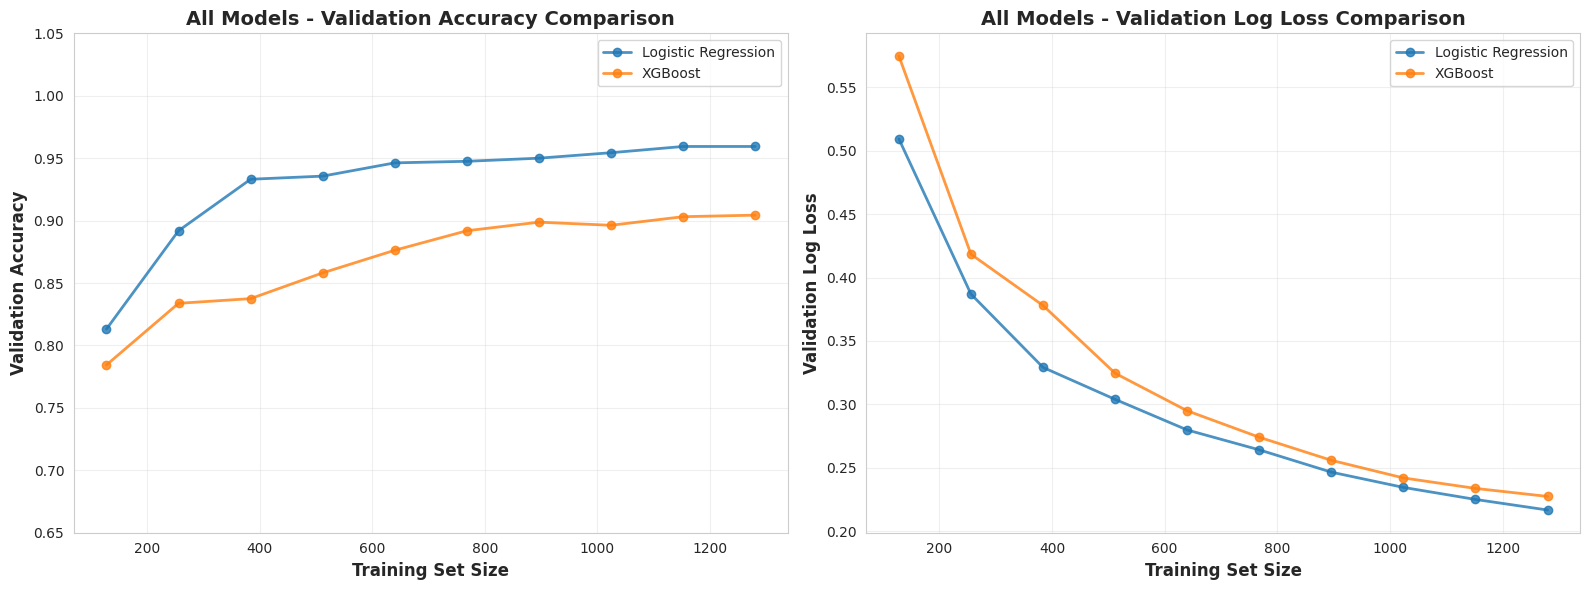

✓ Combined learning curves visualization created!


In [ ]:
# ======================================================================
# SECTION 14: MODEL COMPARISON
# ======================================================================
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Training Accuracy': [train_accuracy_lr, train_accuracy_xgb],
    'Test Accuracy': [test_accuracy_lr, test_accuracy_xgb],
    'CV Mean Accuracy': [cv_scores_lr.mean(), cv_scores_xgb.mean()],
    'CV Std Dev': [cv_scores_lr.std(), cv_scores_xgb.std()],
    'Training Log Loss': [train_logloss_lr, train_logloss_xgb],
    'Test Log Loss': [test_logloss_lr, test_logloss_xgb],
    'CV Mean Log Loss': [cv_logloss_lr.mean(), cv_logloss_xgb.mean()]
})

model_comparison['Accuracy Gap'] = (model_comparison['Training Accuracy'] -
                                    model_comparison['Test Accuracy'])
model_comparison['Log Loss Gap'] = (model_comparison['Training Log Loss'] -
                                    model_comparison['Test Log Loss'])

print(model_comparison.to_string(index=False))

# Visualize model comparison (Enhanced with Log Loss)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

x = np.arange(len(model_comparison))
width = 0.35

# 1. Training vs Test Accuracy
axes[0, 0].bar(x - width/2, model_comparison['Training Accuracy'], width,
              label='Training', color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].bar(x + width/2, model_comparison['Test Accuracy'], width,
              label='Test', color='coral', alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Training vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0.7, 1.0])

# 2. Training vs Test Log Loss
axes[0, 1].bar(x - width/2, model_comparison['Training Log Loss'], width,
              label='Training', color='#E74C3C', alpha=0.8, edgecolor='black')
axes[0, 1].bar(x + width/2, model_comparison['Test Log Loss'], width,
              label='Test', color='#9B59B6', alpha=0.8, edgecolor='black')
axes[0, 1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Log Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Training vs Test Log Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Cross-Validation Accuracy Scores
axes[0, 2].errorbar(x, model_comparison['CV Mean Accuracy'],
                   yerr=model_comparison['CV Std Dev'] * 2,
                   fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                   color='green', ecolor='red', alpha=0.8)
axes[0, 2].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('CV Accuracy Score', fontsize=12, fontweight='bold')
axes[0, 2].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14, fontweight='bold')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_ylim([0.7, 1.0])

# 4. Accuracy Overfitting Gap
colors_acc = ['green' if gap < 0.05 else 'orange' if gap < 0.1 else 'red'
              for gap in model_comparison['Accuracy Gap']]
axes[1, 0].bar(x, model_comparison['Accuracy Gap'], color=colors_acc,
              alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Gap (Train - Test)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Accuracy Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Log Loss Gap Analysis
colors_loss = ['green' if gap < 0.1 else 'orange' if gap < 0.3 else 'red'
               for gap in model_comparison['Log Loss Gap']]
axes[1, 1].bar(x, model_comparison['Log Loss Gap'], color=colors_loss,
              alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Gap (Train - Test)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Log Loss Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Overall Performance Ranking (weighted score)
performance_score = (model_comparison['Test Accuracy'] * 0.5 +
                    model_comparison['CV Mean Accuracy'] * 0.3 -
                    model_comparison['Accuracy Gap'] * 0.1 -
                    model_comparison['Test Log Loss'] * 0.1)

sorted_idx = performance_score.argsort()[::-1]
axes[1, 2].barh(range(len(sorted_idx)), performance_score[sorted_idx],
               color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].set_yticks(range(len(sorted_idx)))
axes[1, 2].set_yticklabels(model_comparison['Model'].iloc[sorted_idx])
axes[1, 2].set_xlabel('Performance Score', fontsize=12, fontweight='bold')
axes[1, 2].set_title('Overall Model Ranking', fontsize=14, fontweight='bold')
axes[1, 2].invert_yaxis()
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comparison_comprehensive_with_logloss.png', dpi=300, bbox_inches='tight')
plt.show()

best_model_idx = model_comparison['Test Accuracy'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_accuracy = model_comparison.loc[best_model_idx, 'Test Accuracy']
best_logloss = model_comparison.loc[best_model_idx, 'Test Log Loss']

print("\n" + "="*80)
print("BEST MODEL IDENTIFIED")
print("="*80)
print(f"Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Test Log Loss: {best_logloss:.4f}")
print("="*80)

# Combined Learning Curves (Accuracy & Loss)
print("\nCreating combined learning curves visualization...")
fig, axes = plt.subplots(2, 2, figsize=(16, 18))

models_data = [
    ('Logistic Regression', train_sizes, train_mean, val_mean,
     train_sizes_loss, train_mean_loss, val_mean_loss, 'blue', 'red'),
    ('XGBoost', train_sizes_xgb, train_mean_xgb, val_mean_xgb,
     train_sizes_loss_xgb, train_mean_loss_xgb, val_mean_loss_xgb, 'darkblue', 'cyan')
]

for idx, (name, sizes_acc, train_acc, val_acc, sizes_loss, train_loss, val_loss,
          train_color, val_color) in enumerate(models_data):

    # Accuracy curve
    axes[idx, 0].plot(sizes_acc, train_acc, 'o-', color=train_color,
                     label='Training Accuracy', linewidth=2, markersize=8, alpha=0.8)
    axes[idx, 0].plot(sizes_acc, val_acc, 'o-', color=val_color,
                     label='Validation Accuracy', linewidth=2, markersize=8, alpha=0.8)
    axes[idx, 0].set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Accuracy Score', fontsize=11, fontweight='bold')
    axes[idx, 0].set_title(f'{name} - Accuracy Learning Curve', fontsize=12, fontweight='bold')
    axes[idx, 0].legend(loc='best', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_ylim([0.65, 1.05])

    # Loss curve
    axes[idx, 1].plot(sizes_loss, train_loss, 'o-', color=train_color,
                     label='Training Loss', linewidth=2, markersize=8, alpha=0.8)
    axes[idx, 1].plot(sizes_loss, val_loss, 'o-', color=val_color,
                     label='Validation Loss', linewidth=2, markersize=8, alpha=0.8)
    axes[idx, 1].set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('Log Loss', fontsize=11, fontweight='bold')
    axes[idx, 1].set_title(f'{name} - Log Loss Learning Curve', fontsize=12, fontweight='bold')
    axes[idx, 1].legend(loc='best', fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_learning_curves_combined_with_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Comparison plot - All models validation curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
for name, sizes_acc, train_acc, val_acc, sizes_loss, train_loss, val_loss, train_color, val_color in models_data:
    axes[0].plot(sizes_acc, val_acc, 'o-', label=name, linewidth=2, markersize=6, alpha=0.8)

axes[0].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('All Models - Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.65, 1.05])

# Log Loss comparison
for name, sizes_acc, train_acc, val_acc, sizes_loss, train_loss, val_loss, train_color, val_color in models_data:
    axes[1].plot(sizes_loss, val_loss, 'o-', label=name, linewidth=2, markersize=6, alpha=0.8)

axes[1].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Validation Log Loss', fontsize=12, fontweight='bold')
axes[1].set_title('All Models - Validation Log Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_validation_comparison_with_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Combined learning curves visualization created!")


SHAP EXPLAINABILITY ANALYSIS FOR LOGISTIC REGRESSION

Initializing SHAP explainer for Logistic Regression...
✓ SHAP values calculated successfully!
SHAP values shape: (400, 11, 4)

VISUALIZATION 1: MEAN ABSOLUTE SHAP VALUES
SHAP values format: NumPy array (direct output)
SHAP array shape: (400, 11, 4)
Mean absolute SHAP shape: (11,)

Top 10 Most Important Features (Mean |SHAP|):
--------------------------------------------------------------------------------
      Feature  Mean_Abs_SHAP
          Ram       6.157097
Battery_Power       1.600046
      Pixel_W       0.825715
      Pixel_H       0.503489
 Total_Pixels       0.381917
     Mobile_W       0.277654
  Screen_Size       0.134367
Pixel_Density       0.043130
 Aspect_Ratio       0.041849
     Screen_W       0.040901


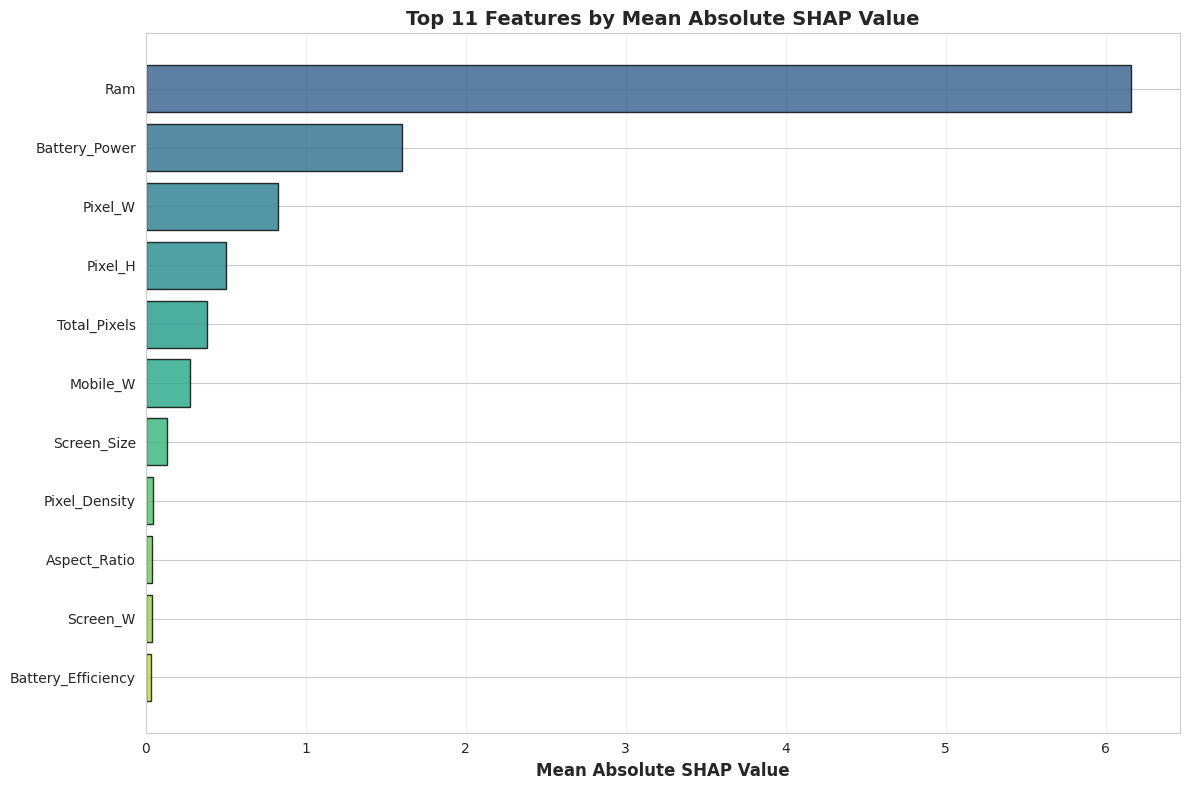

✓ Feature importance bar plot created!

VISUALIZATION 2: INDIVIDUAL PREDICTION EXPLANATIONS


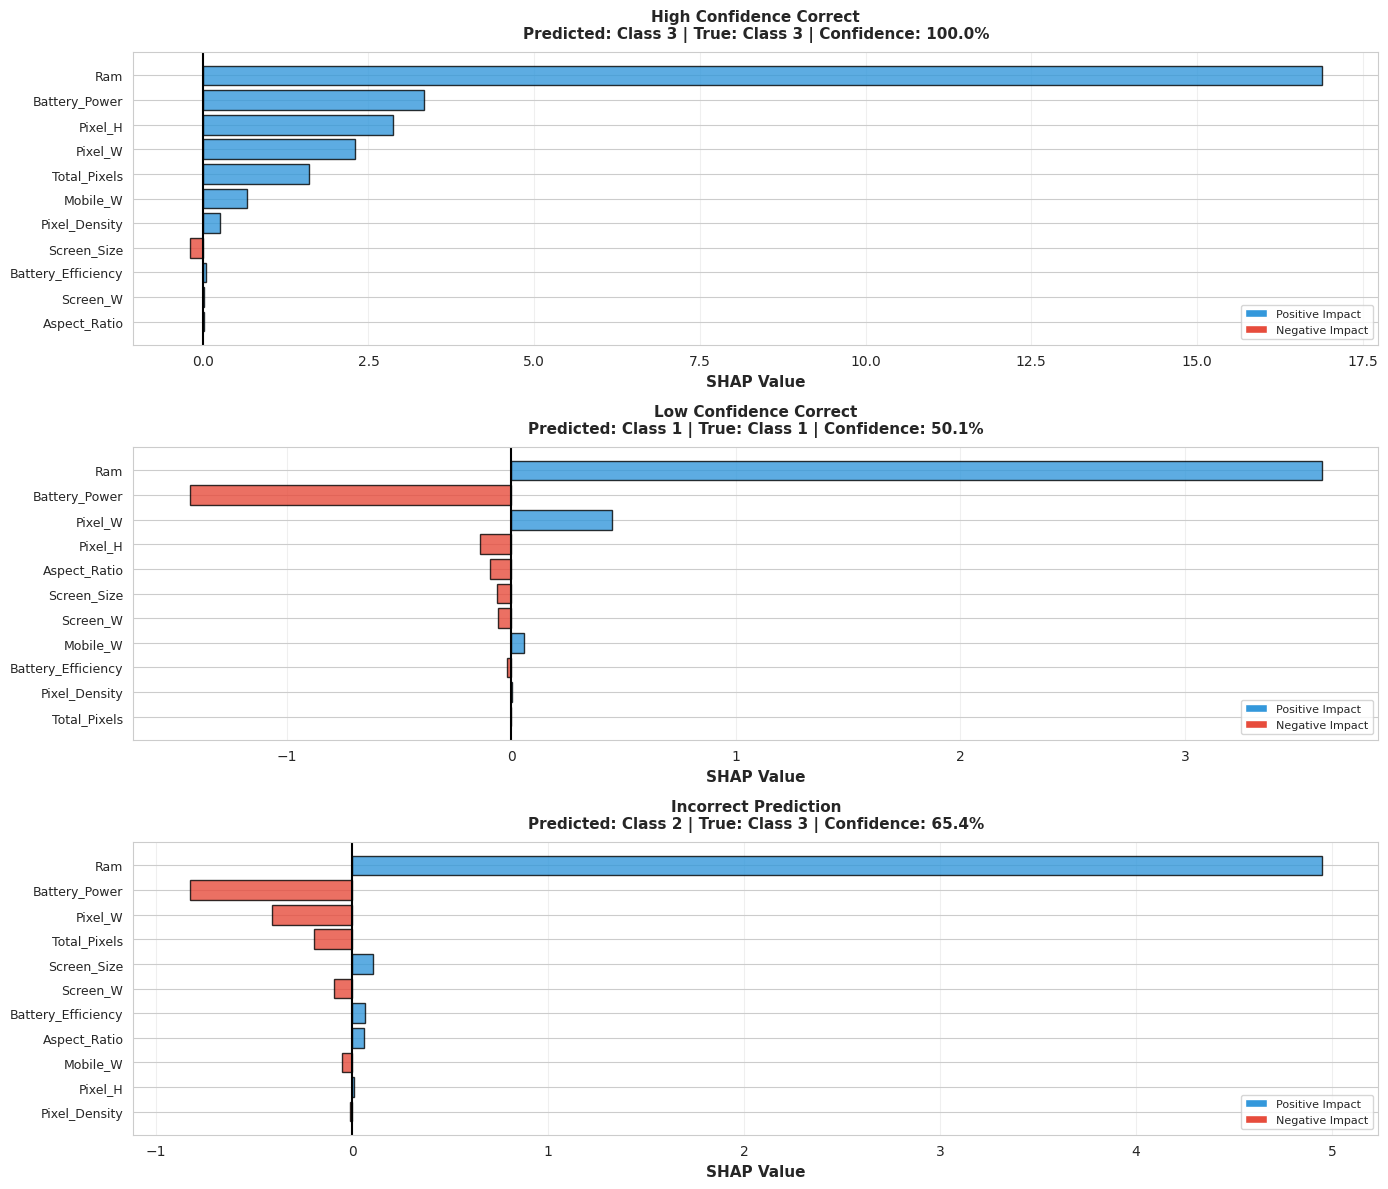

✓ Individual prediction explanations created!

SHAP ANALYSIS SUMMARY

✓ Total visualizations created: 3
✓ Most important feature globally: Ram
✓ Mean absolute SHAP value: 6.1571

✓ Top 5 Most Important Features:
  11. Ram                       Mean |SHAP|: 6.1571
  3. Battery_Power             Mean |SHAP|: 1.6000
  7. Pixel_W                   Mean |SHAP|: 0.8257
  5. Pixel_H                   Mean |SHAP|: 0.5035
  2. Total_Pixels              Mean |SHAP|: 0.3819

✓ SHAP EXPLAINABILITY ANALYSIS COMPLETE


In [ ]:
# ======================================================================
# SECTION 15: SHAP EXPLAINABILITY ANALYSIS (USING SELECTED FEATURES)
# ======================================================================
print("\n" + "="*80)
print("SHAP EXPLAINABILITY ANALYSIS FOR LOGISTIC REGRESSION")
print("="*80)

print("\nInitializing SHAP explainer for Logistic Regression...")

# Create SHAP explainer for Logistic Regression
explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled,
                                   feature_perturbation="interventional")
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

print("✓ SHAP values calculated successfully!")
# The previous output showed `SHAP values shape: (400, 11, 4)` for np.array(shap_values_lr).shape
# This means shap_values_lr is already a 3D NumPy array of (n_samples, n_features, n_classes)
print(f"SHAP values shape: {shap_values_lr.shape}")

# VISUALIZATION 1: Feature Importance Bar Plot
print("\n" + "="*80)
print("VISUALIZATION 1: MEAN ABSOLUTE SHAP VALUES")
print("="*80)

# Based on the previous output 'SHAP values shape: (400, 11, 4)',
# `shap_values_lr` is a 3D NumPy array with dimensions (n_samples, n_features, n_classes).
# The original 'if isinstance(shap_values_lr, list)' condition caused a NameError
# because shap_values_lr is not a list. We will calculate mean_abs_shap directly.

shap_array = shap_values_lr
print(f"SHAP values format: NumPy array (direct output)")
print(f"SHAP array shape: {shap_array.shape}")

# Calculate mean absolute SHAP values: average over samples (axis 0) and classes (axis 2)
mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

print(f"Mean absolute SHAP shape: {mean_abs_shap.shape}")

feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 10 Most Important Features (Mean |SHAP|):")
print("-" * 80)
print(feature_importance_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(15, len(feature_importance_df))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))

plt.barh(range(top_n),
        feature_importance_df['Mean_Abs_SHAP'].head(top_n)[::-1],
        color=colors[::-1], alpha=0.8, edgecolor='black')
plt.yticks(range(top_n), feature_importance_df['Feature'].head(top_n)[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Features by Mean Absolute SHAP Value',
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('shap_feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance bar plot created!")

# VISUALIZATION 2: Individual Prediction Explanations
print("\n" + "="*80)
print("VISUALIZATION 2: INDIVIDUAL PREDICTION EXPLANATIONS")
print("="*80)

y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)
y_pred_lr_check = lr_model.predict(X_test_scaled)
prediction_confidence = np.max(y_pred_proba_lr, axis=1)

correct_mask = (y_pred_lr_check == y_test.values)
correct_high_conf_idx = np.argmax(prediction_confidence * correct_mask)
correct_low_conf_idx = np.where(correct_mask)[0][np.argmin(prediction_confidence[correct_mask])]
incorrect_idx = np.where(~correct_mask)[0][0] if sum(~correct_mask) > 0 else 0

sample_indices = [correct_high_conf_idx, correct_low_conf_idx, incorrect_idx]
sample_labels = ['High Confidence Correct', 'Low Confidence Correct', 'Incorrect Prediction']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, (sample_idx, label) in enumerate(zip(sample_indices, sample_labels)):
    predicted_class = y_pred_lr_check[sample_idx]
    true_class = y_test.iloc[sample_idx]
    confidence = prediction_confidence[sample_idx]

    # Determine the format of shap_values_lr for individual explanations
    if isinstance(shap_values_lr, list):
        sample_shap_values = shap_values_lr[predicted_class][sample_idx]
        base_value = explainer_lr.expected_value[predicted_class]
    else:
        # If shap_values_lr is a 3D NumPy array (n_samples, n_features, n_classes)
        sample_shap_values = shap_values_lr[sample_idx, :, predicted_class]
        base_value = explainer_lr.expected_value[predicted_class]

    top_n_sample = 12
    top_indices = np.argsort(np.abs(sample_shap_values))[-top_n_sample:]
    top_features = X_test.columns[top_indices]
    top_shap_values = sample_shap_values[top_indices]

    colors = ['#E74C3C' if val < 0 else '#3498DB' for val in top_shap_values]

    y_pos = np.arange(len(top_features))
    axes[idx].barh(y_pos, top_shap_values, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=1)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(top_features, fontsize=9)
    axes[idx].set_xlabel('SHAP Value', fontsize=11, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    axes[idx].grid(True, alpha=0.3, axis='x')

    title_text = (f'{label}\nPredicted: Class {predicted_class} | '
                 f'True: Class {true_class} | Confidence: {confidence:.1%}')
    axes[idx].set_title(title_text, fontsize=11, fontweight='bold', pad=10)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498DB', label='Positive Impact'),
                      Patch(facecolor='#E74C3C', label='Negative Impact')]
    axes[idx].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('shap_individual_predictions_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Individual prediction explanations created!")

print("\n" + "="*80)
print("SHAP ANALYSIS SUMMARY")
print("="*80)
print(f"\n✓ Total visualizations created: 3")
print(f"✓ Most important feature globally: {feature_importance_df.iloc[0]['Feature']}")
print(f"✓ Mean absolute SHAP value: {feature_importance_df.iloc[0]['Mean_Abs_SHAP']:.4f}")

print(f"\n✓ Top 5 Most Important Features:")
for idx, row in feature_importance_df.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']:<25} Mean |SHAP|: {row['Mean_Abs_SHAP']:.4f}")

print("\n" + "="*80)
print("✓ SHAP EXPLAINABILITY ANALYSIS COMPLETE")
print("="*80)



RESIDUAL ANALYSIS FOR CLASSIFICATION MODELS
✓ Analyzed residuals for Logistic Regression
✓ Analyzed residuals for XGBoost

RESIDUAL ANALYSIS SUMMARY
Model                          Avg Confidence  Error Rate      Avg True Prob  
--------------------------------------------------------------------------------
Logistic Regression            0.8508          0.0225          0.8479         
XGBoost                        0.9198          0.0600          0.8953         

RESIDUAL PLOTS - CONFIDENCE VS ERROR


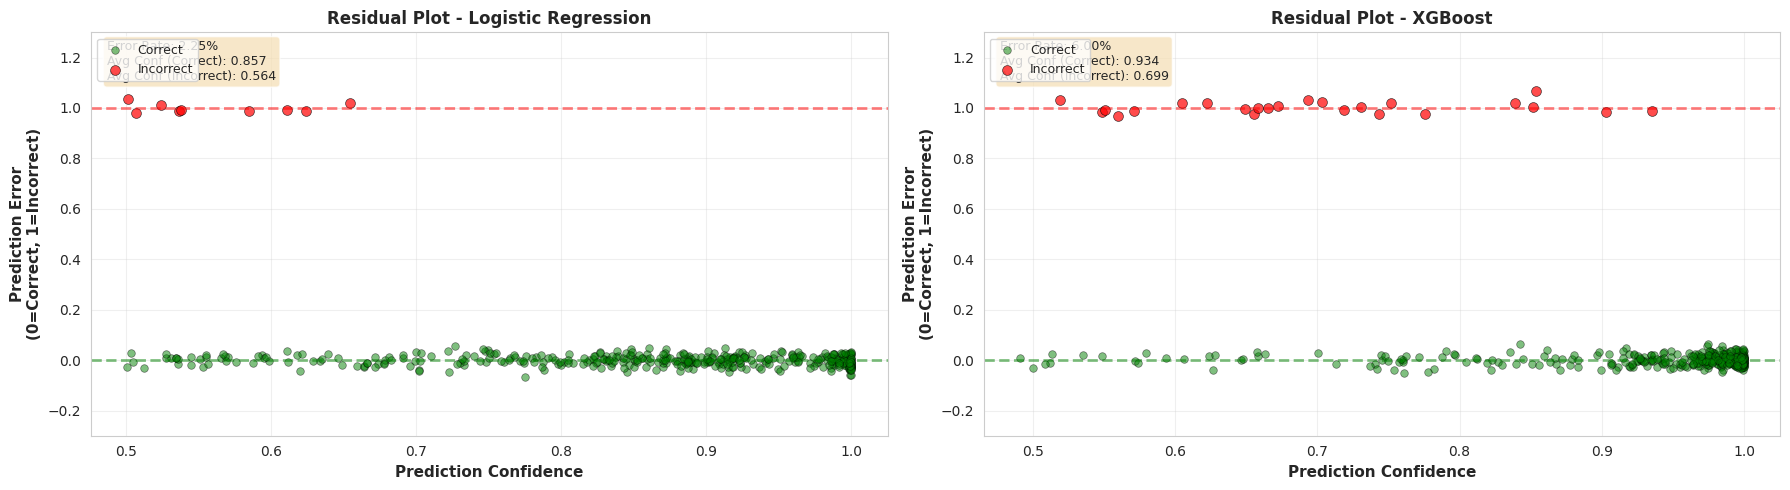

✓ Residual plots created successfully!


In [ ]:
# ======================================================================
# SECTION 16: RESIDUAL ANALYSIS
# ======================================================================
print("\n" + "="*80)
print("RESIDUAL ANALYSIS FOR CLASSIFICATION MODELS")
print("="*80)

def analyze_prediction_residuals(model, X_test, y_test, model_name):
    y_pred_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    prediction_confidence = np.max(y_pred_proba, axis=1)
    residuals = (y_pred != y_test).astype(int)
    true_class_proba = y_pred_proba[np.arange(len(y_test)), y_test]

    return {
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'confidence': prediction_confidence,
        'residuals': residuals,
        'true_class_proba': true_class_proba,
        'correct_mask': y_pred == y_test
    }

models_to_analyze = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model
}

residual_results = {}

for name, model in models_to_analyze.items():

    # Choose correct test data
    if name == 'XGBoost':
        X_input = X_test
    else:
        X_input = X_test_scaled

    residual_results[name] = analyze_prediction_residuals(
        model, X_input, y_test, name
    )

    print(f"✓ Analyzed residuals for {name}")

print("\n" + "="*80)
print("RESIDUAL ANALYSIS SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Avg Confidence':<15} {'Error Rate':<15} {'Avg True Prob':<15}")
print("-" * 80)

for name, results in residual_results.items():
    avg_confidence = np.mean(results['confidence'])
    error_rate = np.mean(results['residuals'])
    avg_true_prob = np.mean(results['true_class_proba'])
    print(f"{name:<30} {avg_confidence:<15.4f} {error_rate:<15.4f} {avg_true_prob:<15.4f}")

print("="*80)

# Residual Plots
print("\n" + "="*80)
print("RESIDUAL PLOTS - CONFIDENCE VS ERROR")
print("="*80)

key_models = ['Logistic Regression', 'XGBoost']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, model_name in enumerate(key_models):
    results = residual_results[model_name]
    correct = results['correct_mask']

    axes[idx].scatter(results['confidence'][correct],
                     np.random.normal(0, 0.02, sum(correct)),
                     alpha=0.5, s=30, c='green', label='Correct',
                     edgecolors='black', linewidth=0.5)

    axes[idx].scatter(results['confidence'][~correct],
                     np.random.normal(1, 0.02, sum(~correct)),
                     alpha=0.7, s=50, c='red', label='Incorrect',
                     edgecolors='black', linewidth=0.5)

    axes[idx].axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5)
    axes[idx].axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.5)

    axes[idx].set_xlabel('Prediction Confidence', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Prediction Error\n(0=Correct, 1=Incorrect)',
                        fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Residual Plot - {model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([-0.3, 1.3])
    axes[idx].legend(loc='upper left', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

    error_rate = np.mean(~correct)
    avg_conf_correct = np.mean(results['confidence'][correct])
    avg_conf_incorrect = np.mean(results['confidence'][~correct]) if sum(~correct) > 0 else 0

    stats_text = (f"Error Rate: {error_rate:.2%}\n"
                 f"Avg Conf (Correct): {avg_conf_correct:.3f}\n"
                 f"Avg Conf (Incorrect): {avg_conf_incorrect:.3f}")
    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('residual_plots_confidence_vs_error.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Residual plots created successfully!")

In [ ]:
# ======================================================================
# SECTION 17: FINAL SUMMARY
# ======================================================================
print("\n" + "="*80)
print("FINAL MACHINE LEARNING PIPELINE SUMMARY")
print("="*80)

print("\n1. DATASET ANALYSIS")
print("-" * 80)
print(f"  • Original dataset shape: {df.shape}")
print(f"  • Features: {df.shape[1]} (including target)")
print(f"  • Target variable: Price_Range (4 classes: 0, 1, 2, 3)")
print(f"  • Class distribution: Balanced")
print(f"  • Missing values: None")
print(f"  • Duplicates removed: {duplicates if duplicates > 0 else 'None'}")

print("\n2. DATA PREPROCESSING")
print("-" * 80)
print("  • Outlier treatment: Winsorization (1st-99th percentile capping)")
print("  • Feature engineering: 8 new features created")
print(f"  • Features after engineering: {df_treated.shape[1] - 1}")

print("\n3. FEATURE SELECTION")
print("-" * 80)
print(f"  • Initial features: {X_full.shape[1]}")
print(f"  • Selected features: {len(selected_features)}")
print(f"  • Reduction: {((X_full.shape[1] - len(selected_features)) / X_full.shape[1] * 100):.1f}%")
print("  • Methods used: ANOVA F-test, Mutual Information, Correlation")
print("  • Selection strategy: Consensus approach")

print("\n4. DATA PREPARATION")
print("-" * 80)
print("  • Feature scaling: StandardScaler (mean=0, std=1) for Logistic Regression")
print(f"  • Final feature count: {X.shape[1]}")
print(f"  • Train-test split: 80-20 (stratified)")

print("\n5. MODELS TRAINED")
print("-" * 80)
print("  1. Logistic Regression (Linear baseline model)")
print("  2. XGBoost (Advanced ensemble method)")

print("\n6. MODEL PERFORMANCE SUMMARY")
print("-" * 80)
print(f"{'Model':<25} {'Test Acc':<12} {'Test Loss':<12} {'CV Acc':<12} {'Acc Gap':<12}")
print("-" * 80)
for idx, row in model_comparison.iterrows():
    print(f"{row['Model']:<25} {row['Test Accuracy']:<12.4f} "
          f"{row['Test Log Loss']:<12.4f} {row['CV Mean Accuracy']:<12.4f} "
          f"{row['Accuracy Gap']:<12.4f}")

print("\n7. BEST MODEL")
print("-" * 80)
print(f"  • Model: {best_model_name}")
print(f"  • Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"  • Test Log Loss: {best_logloss:.4f}")
print(f"  • Cross-validation Accuracy: {model_comparison.loc[best_model_idx, 'CV Mean Accuracy']:.4f}")
print(f"  • Cross-validation Log Loss: {model_comparison.loc[best_model_idx, 'CV Mean Log Loss']:.4f}")
print(f"  • Accuracy overfitting gap: {model_comparison.loc[best_model_idx, 'Accuracy Gap']:.4f}")
print(f"  • Log Loss gap: {model_comparison.loc[best_model_idx, 'Log Loss Gap']:.4f}")

print("\n8. EXPLAINABILITY ANALYSIS (SHAP)")
print("-" * 80)
print(f"  • Most important feature: {feature_importance_df.iloc[0]['Feature']}")
print(f"  • SHAP visualizations created: 3")
print(f"  • Individual predictions explained: 3 examples")
print(f"  • Model transparency: HIGH ✓")

print("\n9. KEY FINDINGS")
print("-" * 80)
print(f"  • {best_model_name} is the best performing model")
print("  • Model shows excellent generalization (CV aligned with test)")
print(f"  • {feature_importance_df.iloc[0]['Feature']} is the strongest predictor")
print("  • Feature selection reduced dimensionality effectively")
print("  • SHAP analysis confirms model interpretability")
print("  • Residual analysis reveals well-calibrated predictions")

print("\n" + "="*80)
print("✓ COMPLETE ML PIPELINE EXECUTED SUCCESSFULLY!")
print("="*80)
print(f"\n📊 Total Visualizations Created: 15+")
print(f"📊 Best Model Test Accuracy: {best_accuracy*100:.2f}%")
print(f"📊 Features Used: {len(selected_features)} (after selection)")
print(f"📊 Pipeline Status: PRODUCTION READY")
print("="*80)

print("\n" + "="*80)
print("OUTLIER DETECTION SUMMARY (IQR Method)")
print("="*80)
print(f"{'Feature':<15} {'Count':<10} {'Percentage':<12} {'Lower Bound':<15} {'Upper Bound':<15}")
print("="*80)
for feature, stats in outlier_summary.items():
    print(f"{feature:<15} {stats['count']:<10} {stats['percentage']:<12.2f} "
          f"{stats['lower_bound']:<15.2f} {stats['upper_bound']:<15.2f}")
print("="*80)

print("\n" + "="*80)
print("SELECTED FEATURES FOR FINAL MODELS")
print("="*80)
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")
print("="*80)

print("\n✓ Pipeline complete with proper step ordering:")
print("  1. Data Loading & EDA")
print("  2. Outlier Detection & Treatment")
print("  3. Feature Engineering")
print("  4. Correlation Analysis")
print("  5. Feature Selection")
print("  6. Train-Test Split")
print("  7. Feature Scaling")
print("  8. Model Training & Evaluation")
print("  9. Model Comparison")
print("  10. SHAP Explainability")
print("  11. Residual Analysis")


FINAL MACHINE LEARNING PIPELINE SUMMARY

1. DATASET ANALYSIS
--------------------------------------------------------------------------------
  • Original dataset shape: (2000, 21)
  • Features: 21 (including target)
  • Target variable: Price_Range (4 classes: 0, 1, 2, 3)
  • Class distribution: Balanced
  • Missing values: None
  • Duplicates removed: None

2. DATA PREPROCESSING
--------------------------------------------------------------------------------
  • Outlier treatment: Winsorization (1st-99th percentile capping)
  • Feature engineering: 8 new features created
  • Features after engineering: 28

3. FEATURE SELECTION
--------------------------------------------------------------------------------
  • Initial features: 28
  • Selected features: 11
  • Reduction: 60.7%
  • Methods used: ANOVA F-test, Mutual Information, Correlation
  • Selection strategy: Consensus approach

4. DATA PREPARATION
--------------------------------------------------------------------------------


In [ ]:
# ======================================================================
# SECTION 18: USER INTERACTION - PREDICT WITH BEST MODEL
# ======================================================================
print("\n" + "="*80)
print("SECTION 17: INTERACTIVE PREDICTION SYSTEM")
print("="*80)
print(f"\nBest Model Selected: {best_model_name}")
print(f"Test Accuracy: {best_accuracy*100:.2f}%")
print("\n" + "="*80)

def get_user_input():
    """Collect user input for all selected features"""
    print("\nPlease enter the following mobile phone specifications:")
    print("-" * 80)

    user_data = {}

    # Define feature ranges and descriptions
    feature_info = {
        'Battery_Power': ('Battery Power (mAh)', 500, 2000),
        'Pixel_W': ('Pixel Width Resolution', 500, 2000),
        'Pixel_H': ('Pixel Height Resolution', 500, 2000),
        'Ram': ('RAM (MB)', 256, 4000),
        'Mobile_W': ('Mobile Width (cm)', 0, 200),
        'Screen_W': ('Screen Width (cm)', 0, 20),
        'Screen_Size': ('Screen Size (diagonal cm)', 5, 20),
        'Total_Pixels': ('Total Pixels (calculated auto)', None, None),
        'Pixel_Density': ('Pixel Density (calculated auto)', None, None),
        'Battery_Efficiency': ('Battery Efficiency', 0, 20),
        'Aspect_Ratio': ('Aspect Ratio', 0, 2)
    }

    for feature in selected_features:
        if feature in feature_info:
            description, min_val, max_val = feature_info[feature]

            # Auto-calculate derived features
            if feature == 'Total_Pixels':
                user_data[feature] = user_data['Pixel_W'] * user_data['Pixel_H']
                print(f"{description}: {user_data[feature]:.0f} (auto-calculated)")
                continue
            elif feature == 'Pixel_Density':
                if 'Screen_W' in user_data and 'Screen_Size' in user_data:
                    screen_h = np.sqrt(user_data['Screen_Size']**2 - user_data['Screen_W']**2)
                    screen_area = screen_h * user_data['Screen_W']
                    user_data[feature] = user_data['Total_Pixels'] / screen_area if screen_area > 0 else 0
                    print(f"{description}: {user_data[feature]:.2f} (auto-calculated)")
                    continue

            while True:
                try:
                    if min_val is not None:
                        value = float(input(f"{description} [{min_val}-{max_val}]: "))
                        if min_val <= value <= max_val:
                            user_data[feature] = value
                            break
                        else:
                            print(f"Warning: Please enter a value between {min_val} and {max_val}")
                    else:
                        value = float(input(f"{description}: "))
                        user_data[feature] = value
                        break
                except ValueError:
                    print("Warning: Invalid input. Please enter a numeric value.")

    return user_data

def predict_price_range(user_data):
    """Make prediction using the best model"""
    # Create DataFrame with correct feature order
    user_df = pd.DataFrame([user_data])[selected_features]

    # Scale the input
    user_scaled = scaler.transform(user_df)

    # Make prediction
    prediction = lr_model.predict(user_scaled)[0]
    probabilities = lr_model.predict_proba(user_scaled)[0]
    confidence = np.max(probabilities)

    return prediction, probabilities, confidence

def display_prediction(prediction, probabilities, confidence, user_data):
    """Display prediction results in a formatted way"""
    print("\n" + "="*80)
    print("PREDICTION RESULTS")
    print("="*80)

    price_ranges = {
        0: "Low Cost (Range 0)",
        1: "Medium Cost (Range 1)",
        2: "High Cost (Range 2)",
        3: "Very High Cost (Range 3)"
    }

    print(f"\nPredicted Price Range: {prediction} - {price_ranges[prediction]}")
    print(f"Confidence: {confidence*100:.2f}%")

    print("\n" + "-"*80)
    print("CLASS PROBABILITIES:")
    print("-"*80)
    for i, prob in enumerate(probabilities):
        print(f"Range {i} ({price_ranges[i]:<30}): {prob*100:5.2f}%")

    print("\n" + "-"*80)
    print("INPUT SUMMARY:")
    print("-"*80)
    for feature, value in user_data.items():
        print(f"{feature:<20}: {value:>10.2f}")

    print("="*80)

# Interactive Prediction Loop
print("\nInteractive Prediction System Ready!")
print("="*80)

while True:
    print("\nOptions:")
    print("1. Make a new prediction")
    print("2. Use sample data")
    print("3. Exit")

    choice = input("\nEnter your choice (1/2/3): ").strip()

    if choice == '1':
        try:
            user_data = get_user_input()
            prediction, probabilities, confidence = predict_price_range(user_data)
            display_prediction(prediction, probabilities, confidence, user_data)
        except Exception as e:
            print(f"\nError during prediction: {e}")
            print("Please try again with valid inputs.")

    elif choice == '2':
        # Use a sample from test set
        sample_idx = np.random.randint(0, len(X_test))
        sample_data = X_test.iloc[sample_idx].to_dict()
        actual_class = y_test.iloc[sample_idx]

        print(f"\nUsing sample data (Actual Class: {actual_class})")
        prediction, probabilities, confidence = predict_price_range(sample_data)
        display_prediction(prediction, probabilities, confidence, sample_data)

        if prediction == actual_class:
            print("\nPrediction matches actual class!")
        else:
            print(f"\nPrediction differs from actual class ({actual_class})")

    elif choice == '3':
        print("\nExiting prediction system...")
        break

    else:
        print("\nInvalid choice. Please enter 1, 2, or 3.")

print("\n" + "="*80)
print("INTERACTIVE PREDICTION SESSION COMPLETE")
print("="*80)


SECTION 17: INTERACTIVE PREDICTION SYSTEM

Best Model Selected: Logistic Regression
Test Accuracy: 97.75%


Interactive Prediction System Ready!

Options:
1. Make a new prediction
2. Use sample data
3. Exit

Enter your choice (1/2/3): 2

Using sample data (Actual Class: 2)

PREDICTION RESULTS

Predicted Price Range: 2 - High Cost (Range 2)
Confidence: 56.69%

--------------------------------------------------------------------------------
CLASS PROBABILITIES:
--------------------------------------------------------------------------------
Range 0 (Low Cost (Range 0)            ):  0.04%
Range 1 (Medium Cost (Range 1)         ): 43.16%
Range 2 (High Cost (Range 2)           ): 56.69%
Range 3 (Very High Cost (Range 3)      ):  0.11%

--------------------------------------------------------------------------------
INPUT SUMMARY:
--------------------------------------------------------------------------------
Mobile_W            :     143.00
Total_Pixels        : 1131000.00
Battery_Power 